# 기본 EDA
전처리(중복 제거)가 끝난 분석용 데이터 `data(drop_duplicated).csv`로, 가사·음향·영상 특징과 조회수의 관계, 장르별 차이, 그리고 **장르 문법에서 벗어난 특이한 곡**을 탐색하는 노트북입니다. 아래 번호 순서가 분석을 진행한 흐름입니다.

| 번호 | 내용 |
|---|---|
| 1-1 | 데이터 확인 (데이터 수, shape, info, 일평균 조회수, 이상치 제외) |
| 1-2 ~ 1-6 | 전반적 EDA 5단계: 데이터 이해 → 단변량 → 조회수와의 관계 → 그룹 비교 → 패턴 발견 |
| 1-7 ~ 1-10 | 가설 확인: 장르별 가사 단순성, 독창성·영어 비중과 인기, 상위 1% 히트곡, 가사 복잡도 통합 지수 |
| 1-11 ~ 1-14 | **특이 케이스**: 장르 문법에서 벗어난 곡 → **edge_case_analysis**로 이어짐 |
| 1-15 | 회귀분석 |
| 1-16 ~ 1-18 | 음향·영상 포함 상관관계, 장르별 오디오 특징 → **variable_selection_decision_tree**로 이어짐 |

> 가사 원문은 노트북에 싣지 않고 가사 지표(복잡도, 영어 비중 등)로만 확인합니다.

In [1]:
# 0. 설정: 라이브러리, 한글 폰트, 데이터 경로
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import f_oneway, ttest_ind, pearsonr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings('ignore')
sns.set_palette("husl")

DATA_FILE = Path("../data/data(drop_duplicated).csv")      # 전처리(deduplication)가 만든 분석용 데이터
REFERENCE_DATE = "2026-02-04"                              # 일평균 조회수 계산의 기준일


def set_korean_font():
    """설치된 한글 폰트를 찾아 matplotlib에 적용한다."""
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ['NanumBarunGothic', 'NanumGothic', 'Malgun Gothic', 'AppleGothic', 'Noto Sans CJK KR']:
        if name in installed:
            plt.rcParams['font.family'] = name
            return name
    for path in ['C:/Windows/Fonts/malgun.ttf', '/mnt/c/Windows/Fonts/malgun.ttf']:   # Windows / WSL
        if Path(path).exists():
            for p in (path, path.replace('malgun.ttf', 'malgunbd.ttf')):      # 일반·굵은 글씨체 등록
                if Path(p).exists():
                    font_manager.fontManager.addfont(p)
            name = font_manager.FontProperties(fname=path).get_name()
            plt.rcParams['font.family'] = name
            return name
    print("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")


print("그래프 한글 폰트:", set_korean_font())
plt.rcParams['axes.unicode_minus'] = False

그래프 한글 폰트: Malgun Gothic


### 1-1. 데이터 확인
**진행 내용**: 시각·청각·가사·장르 정보가 모두 합쳐진 2023~2025년 최종 데이터(`df_final`)를 불러와 데이터 수, shape, info를 확인합니다. 게시일 기준 경과일수로 `daily_view_count`(일평균 조회수)를 계산하고, 이상치를 제외한 뒤 장르 분포를 확인합니다.

In [2]:
df_final = pd.read_csv(DATA_FILE)

print(f"데이터 개수: {len(df_final):,}곡")
print("shape:", df_final.shape)

데이터 개수: 2,043곡
shape: (2043, 59)


In [3]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     2043 non-null   str    
 1   songName                2043 non-null   str    
 2   artists                 2043 non-null   str    
 3   video_id                2043 non-null   str    
 4   api_view_count          2043 non-null   float64
 5   api_like_count          2043 non-null   float64
 6   api_comment_count       2043 non-null   float64
 7   api_published_at        2043 non-null   str    
 8   api_duration            2043 non-null   str    
 9   api_channel_title       2043 non-null   str    
 10  valence_raw             2043 non-null   float64
 11  arousal_raw             2043 non-null   float64
 12  valence_normalized      2043 non-null   float64
 13  arousal_normalized      2043 non-null   float64
 14  energy                  2043 non-null   float64
 15

In [4]:
import pandas as pd

# 1. 'api_published_at' 컬럼을 datetime 형식으로 변환합니다.
# (UTC 시간대 설정을 통해 계산의 일관성을 유지합니다)
df_final['api_published_at'] = pd.to_datetime(df_final['api_published_at'], utc=True, format='mixed')

# 2. 기준 시점(2026년 2월 4일)을 설정합니다.
reference_date = pd.to_datetime('2026-02-04').tz_localize('UTC')

# 3. 기준 시점으로부터의 경과 일수를 계산합니다.
# 게시 당일 조회수가 0으로 나누어지는 것을 방지하기 위해 최소값을 1일로 설정(clip)합니다.
days_diff = (reference_date - df_final['api_published_at']).dt.days
days_diff = days_diff.clip(lower=1)

# 4. daily_view_count 컬럼을 생성합니다 (총 조회수 / 경과 일수)
df_final['daily_view_count'] = df_final['api_view_count'] / days_diff

# 결과 확인을 위해 주요 컬럼만 출력해볼 수 있습니다.
print(df_final[['songName', 'api_view_count', 'api_published_at', 'daily_view_count']].head())

                 songName  api_view_count          api_published_at  \
0         number one girl     138041277.0 2024-11-22 05:00:06+00:00   
1  Love Potion (백일몽; 白日夢)       2466382.0 2024-12-30 09:00:43+00:00   
2                    IZNA      65949656.0 2024-11-25 09:00:07+00:00   
3                No Doubt      82028550.0 2024-11-11 08:56:07+00:00   
4                  SHEESH     391040639.0 2024-03-31 15:00:08+00:00   

   daily_view_count  
0     315162.732877  
1       6165.955000  
2     151608.404598  
3     182691.648107  
4     580178.989614  


In [5]:
exclude_ids = ['cSqOY5nktfg', 'pOVNGANwcrk', '0RvaJ9hOkw8']
# ~ 표시가 '포함되지 않은 것만 선택'한다는 의미입니다.
before = df_final
df_final = df_final[~df_final['video_id'].isin(exclude_ids)].copy()

print(f"✅ 필터링 완료: 현재 데이터 개수 {len(df_final):,}개 ({len(before) - len(df_final)}개 제거됨)")

✅ 필터링 완료: 현재 데이터 개수 2,042개 (1개 제거됨)


In [6]:
df_final['genie_genre'].value_counts()

genie_genre
댄스        908
발라드       356
락         259
R&B/소울    212
랩/힙합      187
인디         60
일렉트로니카     40
팝          20
Name: count, dtype: int64

### 1-2. 전반적 EDA — Phase 1: 데이터 이해하기
특정 가설 검증에 들어가기 전에, 데이터 전체를 폭넓게 훑어보는 5단계 자동화 EDA입니다. 기본 통계, 결측치, 연도별 분포, 가사 변수들의 기술통계량을 확인합니다.

🎵 K-POP 뮤직비디오 가사 특성 종합 EDA 시작

PHASE 1: 데이터 이해하기

[1.1 데이터 기본 정보]
총 곡 수: 2042
총 변수 수: 60

데이터 타입:
float64                36
str                    13
int64                  10
datetime64[us, UTC]     1
Name: count, dtype: int64

결측치 현황:
Empty DataFrame
Columns: [결측치 수, 결측치 비율(%)]
Index: []

연도별 분포:
year
2023    747
2024    617
2025    678
Name: count, dtype: int64

가사 변수 기술 통계량:


                         count        mean         std     min         25%        50%         75%        max  skewness   kurtosis
sentiment_compound      2042.0    0.405794    0.388106 -0.9440    0.090600    0.22310    0.829000     0.9875  0.155076  -1.351435
sentiment_positive      2042.0    0.584017    0.294049  0.0280    0.323325    0.40055    0.914525     0.9937  0.236017  -1.748850
sentiment_negative      2042.0    0.178223    0.112000  0.0063    0.085475    0.18770    0.239500     0.9720  1.127880   4.396228
sentiment_neutral       2042.0    0.329353    0.168096  0.0125    0.170225    0.40945    0.445100     0.9971 -0.295754  -0.385515
token_count             2042.0  376.706660  147.105024  5.0000  266.000000  366.00000  468.000000  1706.0000  1.145704   5.800889
unique_token_ratio      2042.0    0.397084    0.097861  0.0893    0.329025    0.39125    0.458075     1.0000  0.657217   2.514829
repeated_token_ratio    2042.0    0.602916    0.097861  0.0000    0.541925    0.60875    0

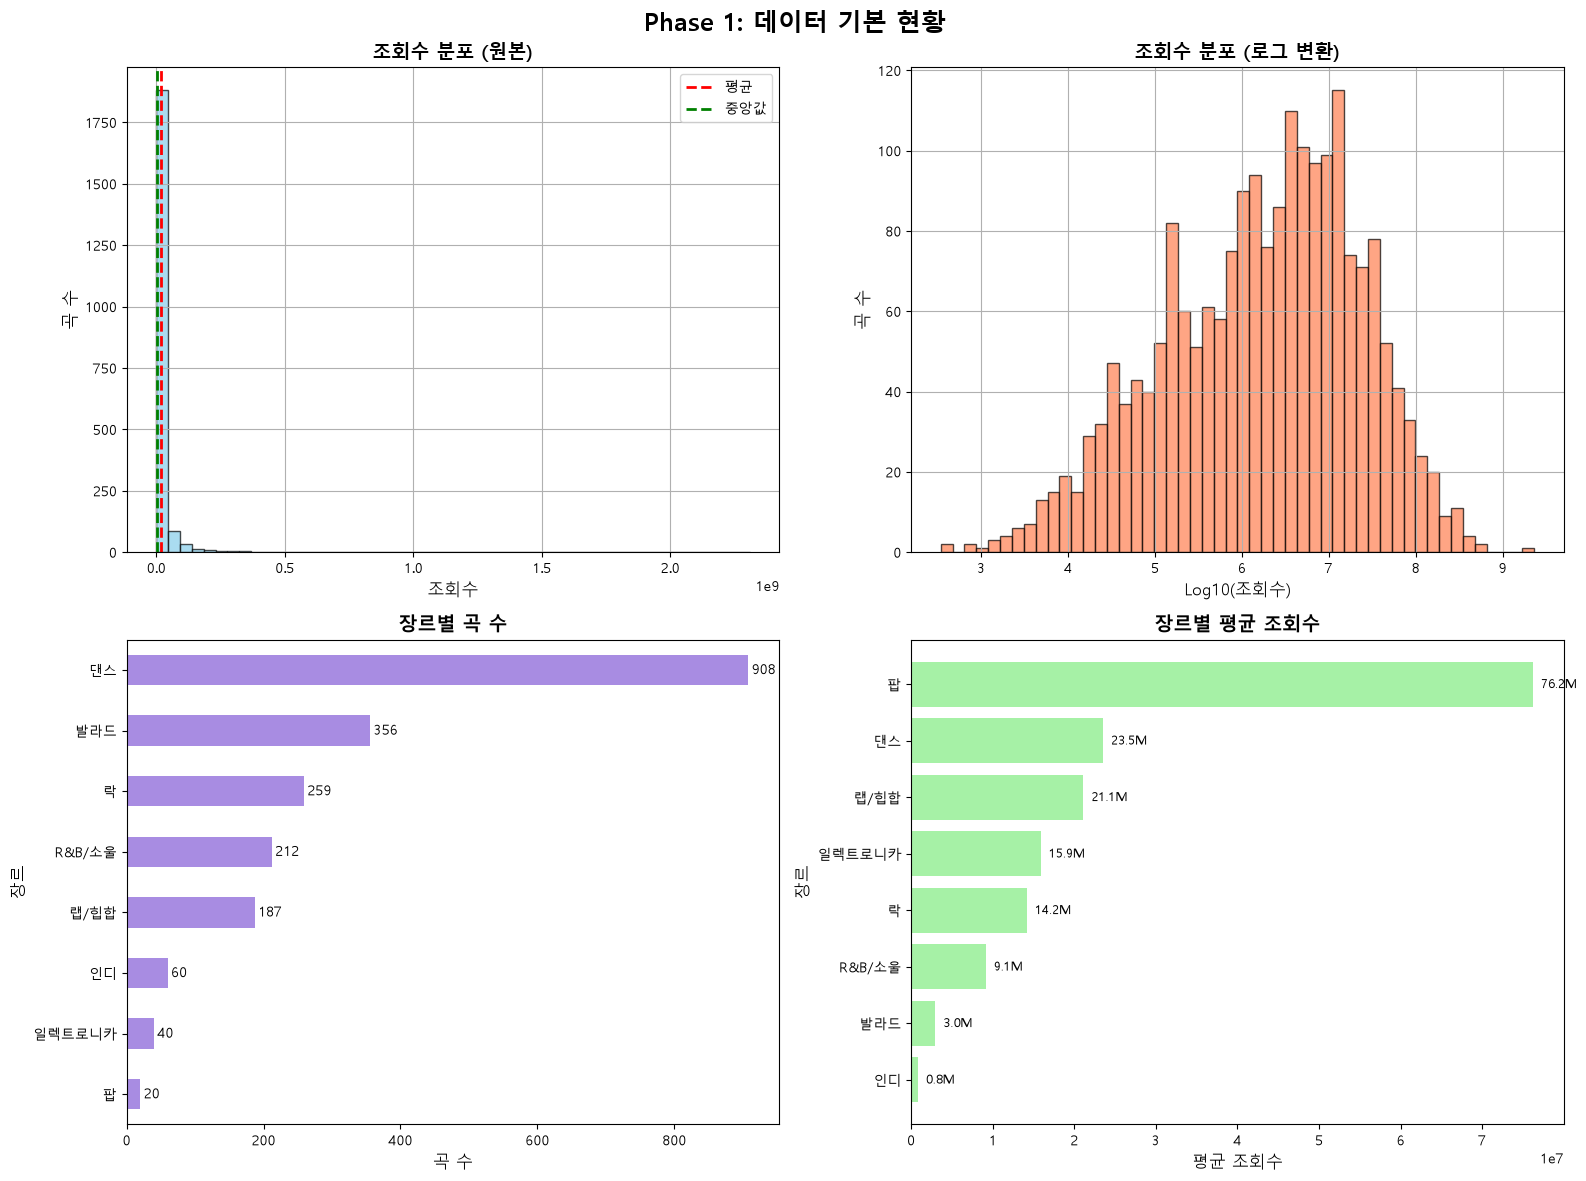

In [7]:
print("="*100)
print("🎵 K-POP 뮤직비디오 가사 특성 종합 EDA 시작")
print("="*100)

# ============================================
# PHASE 1: 데이터 이해하기 (Foundation)
# ============================================

print("\n" + "="*100)
print("PHASE 1: 데이터 이해하기")
print("="*100)

# 1.1 기본 통계
print("\n[1.1 데이터 기본 정보]")
print(f"총 곡 수: {len(df_final)}")
print(f"총 변수 수: {len(df_final.columns)}")
print(f"\n데이터 타입:")
print(df_final.dtypes.value_counts())

# 결측치 확인
print(f"\n결측치 현황:")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final) * 100).round(2)
missing_df = pd.DataFrame({
    '결측치 수': missing[missing > 0],
    '결측치 비율(%)': missing_pct[missing > 0]
})
print(missing_df.to_string())

print(f"\n연도별 분포:")
print(df_final['year'].value_counts().sort_index())

# 가사 변수 정의
lyrics_features = [
    'sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral',
    'token_count', 'unique_token_ratio', 'repeated_token_ratio', 'avg_token_length',
    'hapax_legomenon', 'hapax_dislegomenon', 'hapax_trislegomenon',
    'line_count', 'avg_tokens_per_line', 'unique_tokens_per_line',
    'punctuation_ratio', 'compression_rate', 'pronoun_frequency',
    'korean_ratio', 'english_ratio'
]

# 기술 통계량
print(f"\n가사 변수 기술 통계량:")
desc_stats = df_final[lyrics_features].describe().T
desc_stats['skewness'] = df_final[lyrics_features].skew()
desc_stats['kurtosis'] = df_final[lyrics_features].kurtosis()
print(desc_stats.to_string())

# 조회수 기본 분석
print(f"\n조회수 기본 통계:")
print(df_final['api_view_count'].describe())
print(f"\n조회수 구간별 분포:")
view_bins = [0, 1e6, 10e6, 50e6, 100e6, np.inf]
view_labels = ['<1M', '1-10M', '10-50M', '50-100M', '>100M']
df_final['view_segment'] = pd.cut(df_final['api_view_count'], bins=view_bins, labels=view_labels)
print(df_final['view_segment'].value_counts().sort_index())

# 1.2 장르 분포
print(f"\n[1.2 장르 분포]")
genre_stats = df_final.groupby('genie_genre').agg({
    'api_view_count': ['count', 'mean', 'median', 'std']
}).round(0)
genre_stats.columns = ['곡수', '평균_조회수', '중앙값_조회수', '표준편차']
genre_stats = genre_stats.sort_values('평균_조회수', ascending=False)
print(genre_stats.to_string())

# Phase 1 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phase 1: 데이터 기본 현황', fontsize=18, fontweight='bold')

# 1. 조회수 분포
ax1 = axes[0, 0]
df_final['api_view_count'].hist(bins=50, ax=ax1, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('조회수', fontsize=12)
ax1.set_ylabel('곡 수', fontsize=12)
ax1.set_title('조회수 분포 (원본)', fontsize=14, fontweight='bold')
ax1.axvline(df_final['api_view_count'].mean(), color='red', linestyle='--', linewidth=2, label='평균')
ax1.axvline(df_final['api_view_count'].median(), color='green', linestyle='--', linewidth=2, label='중앙값')
ax1.legend()

# 2. 조회수 분포 (로그 변환)
ax2 = axes[0, 1]
np.log10(df_final['api_view_count'] + 1).hist(bins=50, ax=ax2, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Log10(조회수)', fontsize=12)
ax2.set_ylabel('곡 수', fontsize=12)
ax2.set_title('조회수 분포 (로그 변환)', fontsize=14, fontweight='bold')

# 3. 장르별 곡 수
ax3 = axes[1, 0]
genre_counts = df_final['genie_genre'].value_counts().sort_values(ascending=True)
genre_counts.plot(kind='barh', ax=ax3, color='mediumpurple', alpha=0.8)
ax3.set_xlabel('곡 수', fontsize=12)
ax3.set_ylabel('장르', fontsize=12)
ax3.set_title('장르별 곡 수', fontsize=14, fontweight='bold')
for i, v in enumerate(genre_counts.values):
    ax3.text(v + 5, i, str(v), va='center', fontsize=10)

# 4. 장르별 평균 조회수
ax4 = axes[1, 1]
genre_views = df_final.groupby('genie_genre')['api_view_count'].mean().sort_values(ascending=True)
bars = ax4.barh(range(len(genre_views)), genre_views.values, color='lightgreen', alpha=0.8)
ax4.set_yticks(range(len(genre_views)))
ax4.set_yticklabels(genre_views.index)
ax4.set_xlabel('평균 조회수', fontsize=12)
ax4.set_ylabel('장르', fontsize=12)
ax4.set_title('장르별 평균 조회수', fontsize=14, fontweight='bold')
for i, v in enumerate(genre_views.values):
    ax4.text(v + 1e6, i, f'{v/1e6:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 1-3. 전반적 EDA — Phase 2: 단변량 분석
주요 변수들의 분포(히스토그램/박스플롯)를 개별적으로 확인합니다.


PHASE 2: 단변량 분석

[2.1 감정 변수 분석]
                     count      mean       std     min       25%      50%  \
sentiment_compound  2042.0  0.405794  0.388106 -0.9440  0.090600  0.22310   
sentiment_positive  2042.0  0.584017  0.294049  0.0280  0.323325  0.40055   
sentiment_negative  2042.0  0.178223  0.112000  0.0063  0.085475  0.18770   
sentiment_neutral   2042.0  0.329353  0.168096  0.0125  0.170225  0.40945   

                         75%     max  
sentiment_compound  0.829000  0.9875  
sentiment_positive  0.914525  0.9937  
sentiment_negative  0.239500  0.9720  
sentiment_neutral   0.445100  0.9971  

감정 카테고리 분포:
emotion_category
긍정적    1695
중립      221
부정적     126
Name: count, dtype: int64

[2.2 복잡도/다양성 변수 분석]
                       count        mean         std     min         25%  \
token_count           2042.0  376.706660  147.105024  5.0000  266.000000   
unique_token_ratio    2042.0    0.397084    0.097861  0.0893    0.329025   
repeated_token_ratio  2042.0    0.602916    0

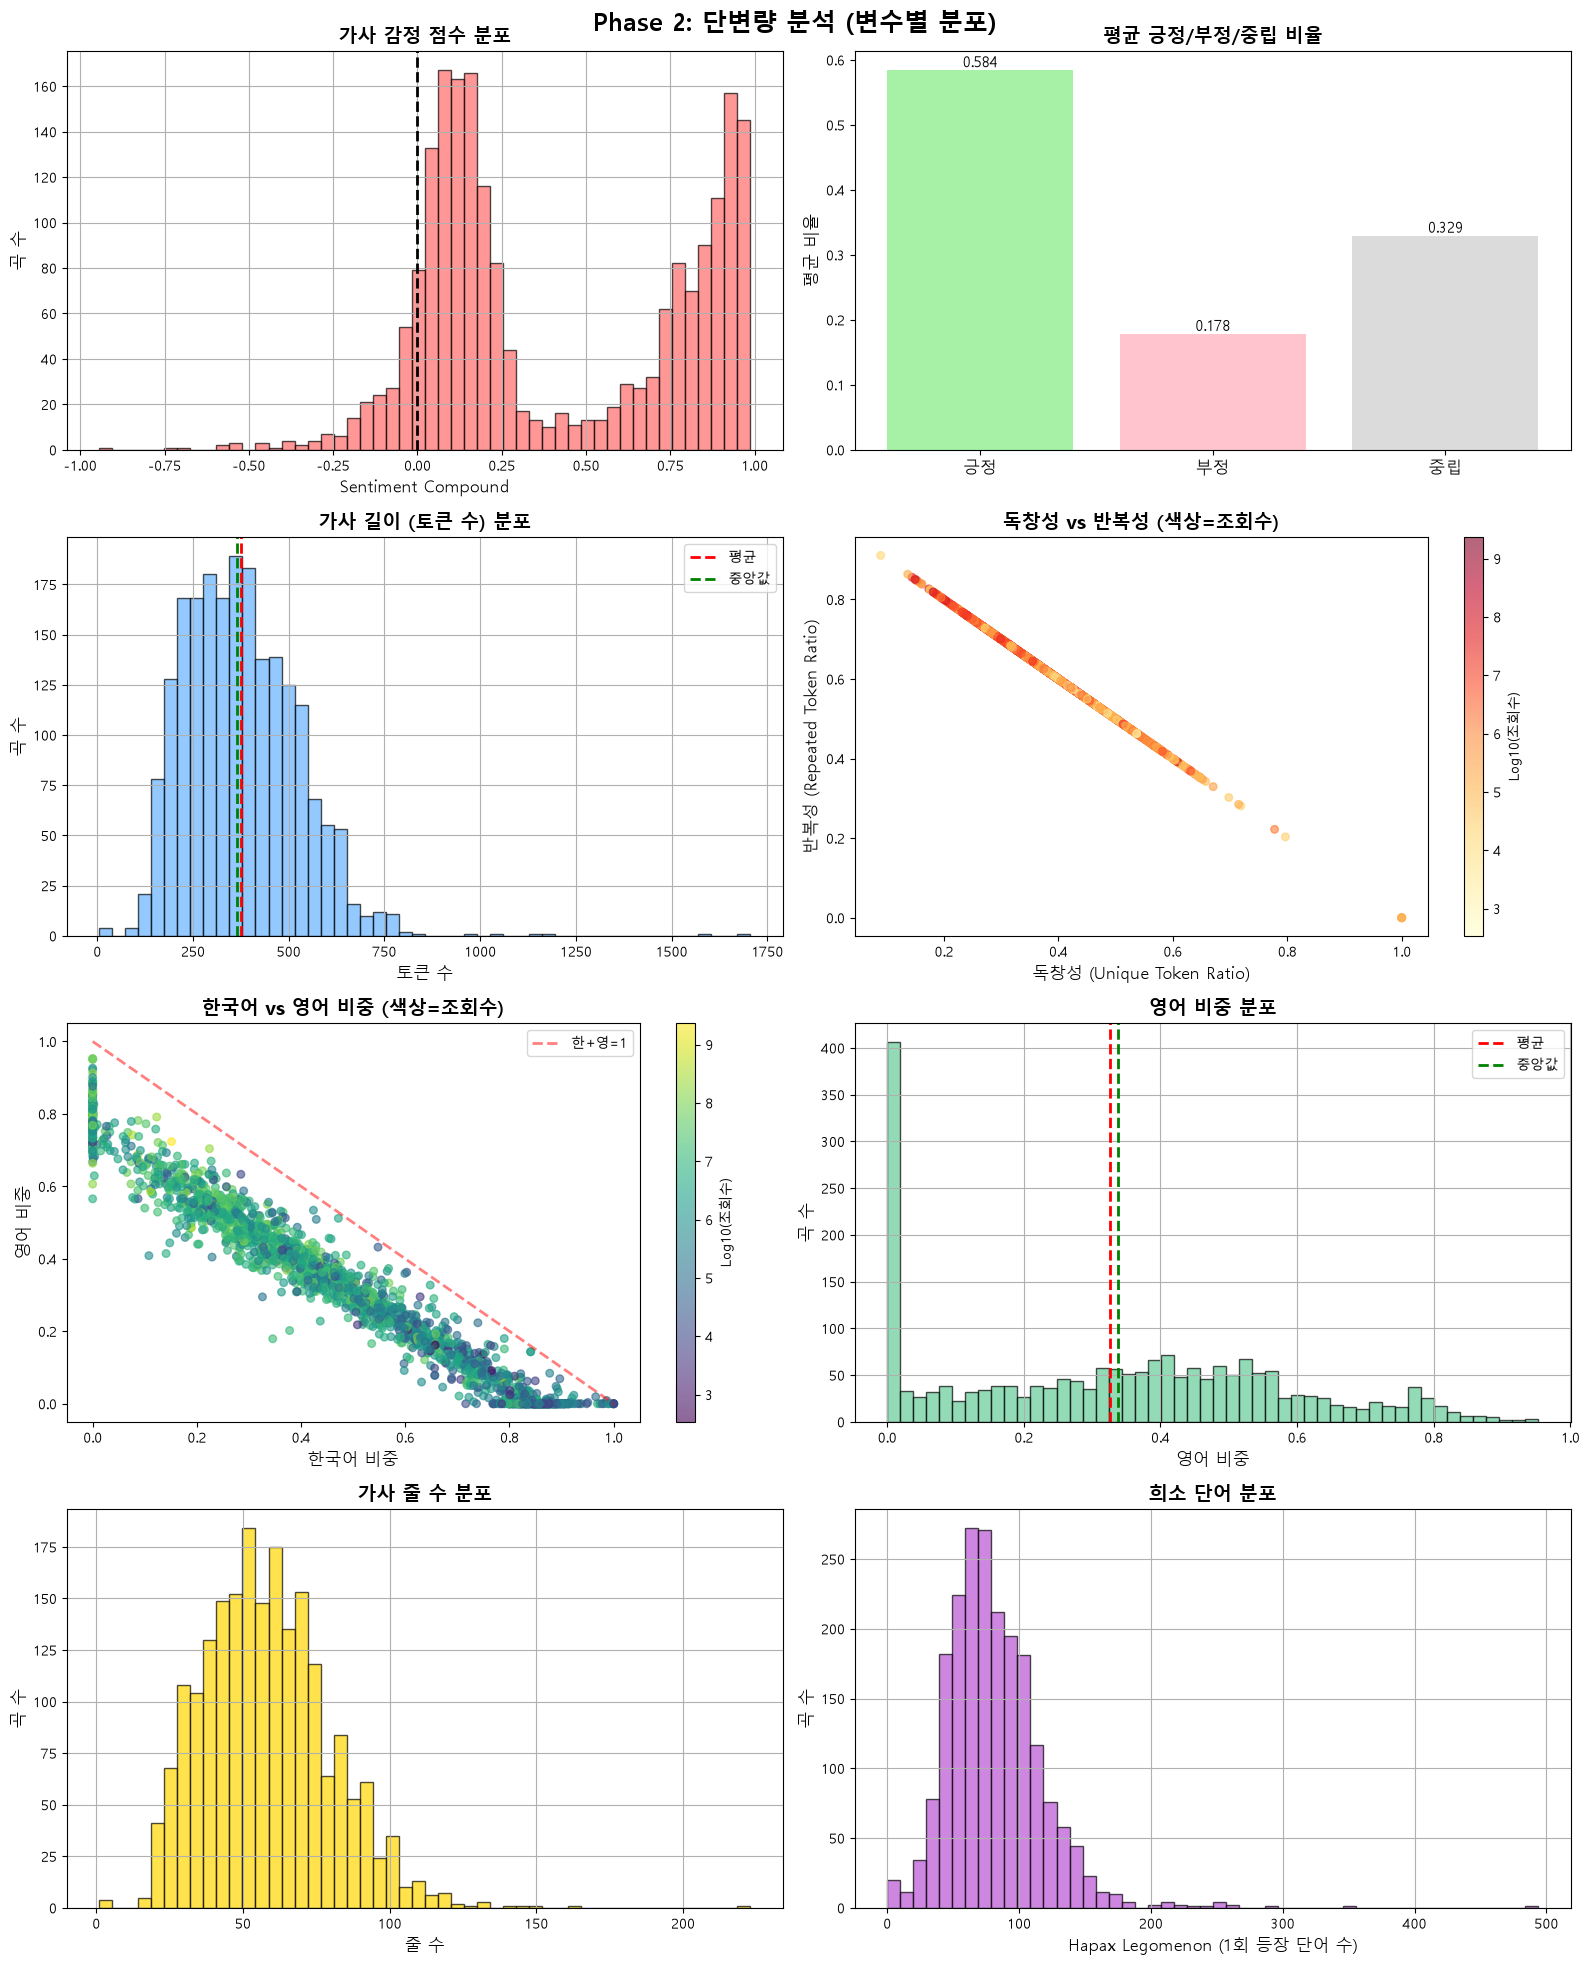

In [8]:
# ============================================
# PHASE 2: 단변량 분석 (각 변수 깊게 파기)
# ============================================

print("\n" + "="*100)
print("PHASE 2: 단변량 분석")
print("="*100)

# 2.1 감정 변수
print("\n[2.1 감정 변수 분석]")
sentiment_vars = ['sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral']
print(df_final[sentiment_vars].describe().T)

# 감정 분류
df_final['emotion_category'] = pd.cut(
    df_final['sentiment_compound'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['부정적', '중립', '긍정적']
)
print(f"\n감정 카테고리 분포:")
print(df_final['emotion_category'].value_counts())

# 2.2 복잡도/다양성 변수
print("\n[2.2 복잡도/다양성 변수 분석]")
complexity_vars = ['token_count', 'unique_token_ratio', 'repeated_token_ratio', 'avg_token_length']
print(df_final[complexity_vars].describe().T)

print(f"\n독창성 vs 반복성 상관관계: {df_final['unique_token_ratio'].corr(df_final['repeated_token_ratio']):.4f}")

# 2.3 언어 변수 (중요!)
print("\n[2.3 언어 변수 분석]")
print(f"\n한국어 비중 분포:")
print(df_final['korean_ratio'].describe())
print(f"\n영어 비중 분포:")
print(df_final['english_ratio'].describe())

# 언어 카테고리
df_final['language_category'] = pd.cut(
    df_final['english_ratio'],
    bins=[-0.01, 0.1, 0.3, 0.5, 0.7, 1.01],
    labels=['거의 한국어', '한국어 위주', '혼합', '영어 위주', '거의 영어']
)
print(f"\n언어 카테고리 분포:")
print(df_final['language_category'].value_counts().sort_index())

# Phase 2 시각화 (8개 subplot)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Phase 2: 단변량 분석 (변수별 분포)', fontsize=18, fontweight='bold')

# 1. 감정 점수 분포
ax1 = axes[0, 0]
df_final['sentiment_compound'].hist(bins=50, ax=ax1, color='#FF6B6B', edgecolor='black', alpha=0.7)
ax1.axvline(0, color='black', linestyle='--', linewidth=2)
ax1.set_xlabel('Sentiment Compound', fontsize=12)
ax1.set_ylabel('곡 수', fontsize=12)
ax1.set_title('가사 감정 점수 분포', fontsize=14, fontweight='bold')

# 2. 긍정/부정/중립 비율
ax2 = axes[0, 1]
sentiment_means = df_final[['sentiment_positive', 'sentiment_negative', 'sentiment_neutral']].mean()
colors = ['#90EE90', '#FFB6C1', '#D3D3D3']
bars = ax2.bar(range(len(sentiment_means)), sentiment_means.values, color=colors, alpha=0.8)
ax2.set_xticks(range(len(sentiment_means)))
ax2.set_xticklabels(['긍정', '부정', '중립'], fontsize=12)
ax2.set_ylabel('평균 비율', fontsize=12)
ax2.set_title('평균 긍정/부정/중립 비율', fontsize=14, fontweight='bold')
for bar, val in zip(bars, sentiment_means.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11)

# 3. 토큰 수 분포
ax3 = axes[1, 0]
df_final['token_count'].hist(bins=50, ax=ax3, color='#66B2FF', edgecolor='black', alpha=0.7)
ax3.axvline(df_final['token_count'].mean(), color='red', linestyle='--', linewidth=2, label='평균')
ax3.axvline(df_final['token_count'].median(), color='green', linestyle='--', linewidth=2, label='중앙값')
ax3.set_xlabel('토큰 수', fontsize=12)
ax3.set_ylabel('곡 수', fontsize=12)
ax3.set_title('가사 길이 (토큰 수) 분포', fontsize=14, fontweight='bold')
ax3.legend()

# 4. 독창성 vs 반복성 산점도
ax4 = axes[1, 1]
scatter = ax4.scatter(df_final['unique_token_ratio'], df_final['repeated_token_ratio'],
                     c=np.log10(df_final['api_view_count']+1), cmap='YlOrRd', alpha=0.6, s=30)
ax4.set_xlabel('독창성 (Unique Token Ratio)', fontsize=12)
ax4.set_ylabel('반복성 (Repeated Token Ratio)', fontsize=12)
ax4.set_title('독창성 vs 반복성 (색상=조회수)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax4, label='Log10(조회수)')

# 5. 한국어 vs 영어 비중
ax5 = axes[2, 0]
scatter = ax5.scatter(df_final['korean_ratio'], df_final['english_ratio'],
                     c=np.log10(df_final['api_view_count']+1), cmap='viridis', alpha=0.6, s=30)
ax5.plot([0, 1], [1, 0], 'r--', linewidth=2, alpha=0.5, label='한+영=1')
ax5.set_xlabel('한국어 비중', fontsize=12)
ax5.set_ylabel('영어 비중', fontsize=12)
ax5.set_title('한국어 vs 영어 비중 (색상=조회수)', fontsize=14, fontweight='bold')
ax5.legend()
plt.colorbar(scatter, ax=ax5, label='Log10(조회수)')

# 6. 영어 비중 분포
ax6 = axes[2, 1]
df_final['english_ratio'].hist(bins=50, ax=ax6, color='#66CC99', edgecolor='black', alpha=0.7)
ax6.axvline(df_final['english_ratio'].mean(), color='red', linestyle='--', linewidth=2, label='평균')
ax6.axvline(df_final['english_ratio'].median(), color='green', linestyle='--', linewidth=2, label='중앙값')
ax6.set_xlabel('영어 비중', fontsize=12)
ax6.set_ylabel('곡 수', fontsize=12)
ax6.set_title('영어 비중 분포', fontsize=14, fontweight='bold')
ax6.legend()

# 7. 줄 수 분포
ax7 = axes[3, 0]
df_final['line_count'].hist(bins=50, ax=ax7, color='#FFD700', edgecolor='black', alpha=0.7)
ax7.set_xlabel('줄 수', fontsize=12)
ax7.set_ylabel('곡 수', fontsize=12)
ax7.set_title('가사 줄 수 분포', fontsize=14, fontweight='bold')

# 8. Hapax Legomenon 분포
ax8 = axes[3, 1]
df_final['hapax_legomenon'].hist(bins=50, ax=ax8, color='#BA55D3', edgecolor='black', alpha=0.7)
ax8.set_xlabel('Hapax Legomenon (1회 등장 단어 수)', fontsize=12)
ax8.set_ylabel('곡 수', fontsize=12)
ax8.set_title('희소 단어 분포', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 1-4. 전반적 EDA — Phase 3: 타겟변수(조회수) 관계 분석
각 변수와 조회수 간의 관계(상관관계, 산점도)를 탐색합니다.


PHASE 3: 타겟 변수(조회수)와의 관계

[3.1 상관관계 분석]
                        변수      상관계수       p-value  유의함        효과크기
18           english_ratio  0.190854  3.342124e-18  Yes       Small
17            korean_ratio -0.177028  7.725507e-16  Yes       Small
7         avg_token_length  0.175791  1.231732e-15  Yes       Small
5       unique_token_ratio -0.124689  1.575485e-08  Yes       Small
6     repeated_token_ratio  0.124689  1.575549e-08  Yes       Small
11              line_count  0.110056  6.184033e-07  Yes       Small
4              token_count  0.108352  9.214587e-07  Yes       Small
15        compression_rate -0.105244  1.877924e-06  Yes       Small
14       punctuation_ratio  0.070733  1.382042e-03  Yes  Negligible
16       pronoun_frequency  0.059671  6.992634e-03  Yes  Negligible
1       sentiment_positive  0.046787  3.450745e-02  Yes  Negligible
0       sentiment_compound  0.038466  8.224947e-02   No  Negligible
12     avg_tokens_per_line  0.032741  1.391366e-01   No  Negligible
9      

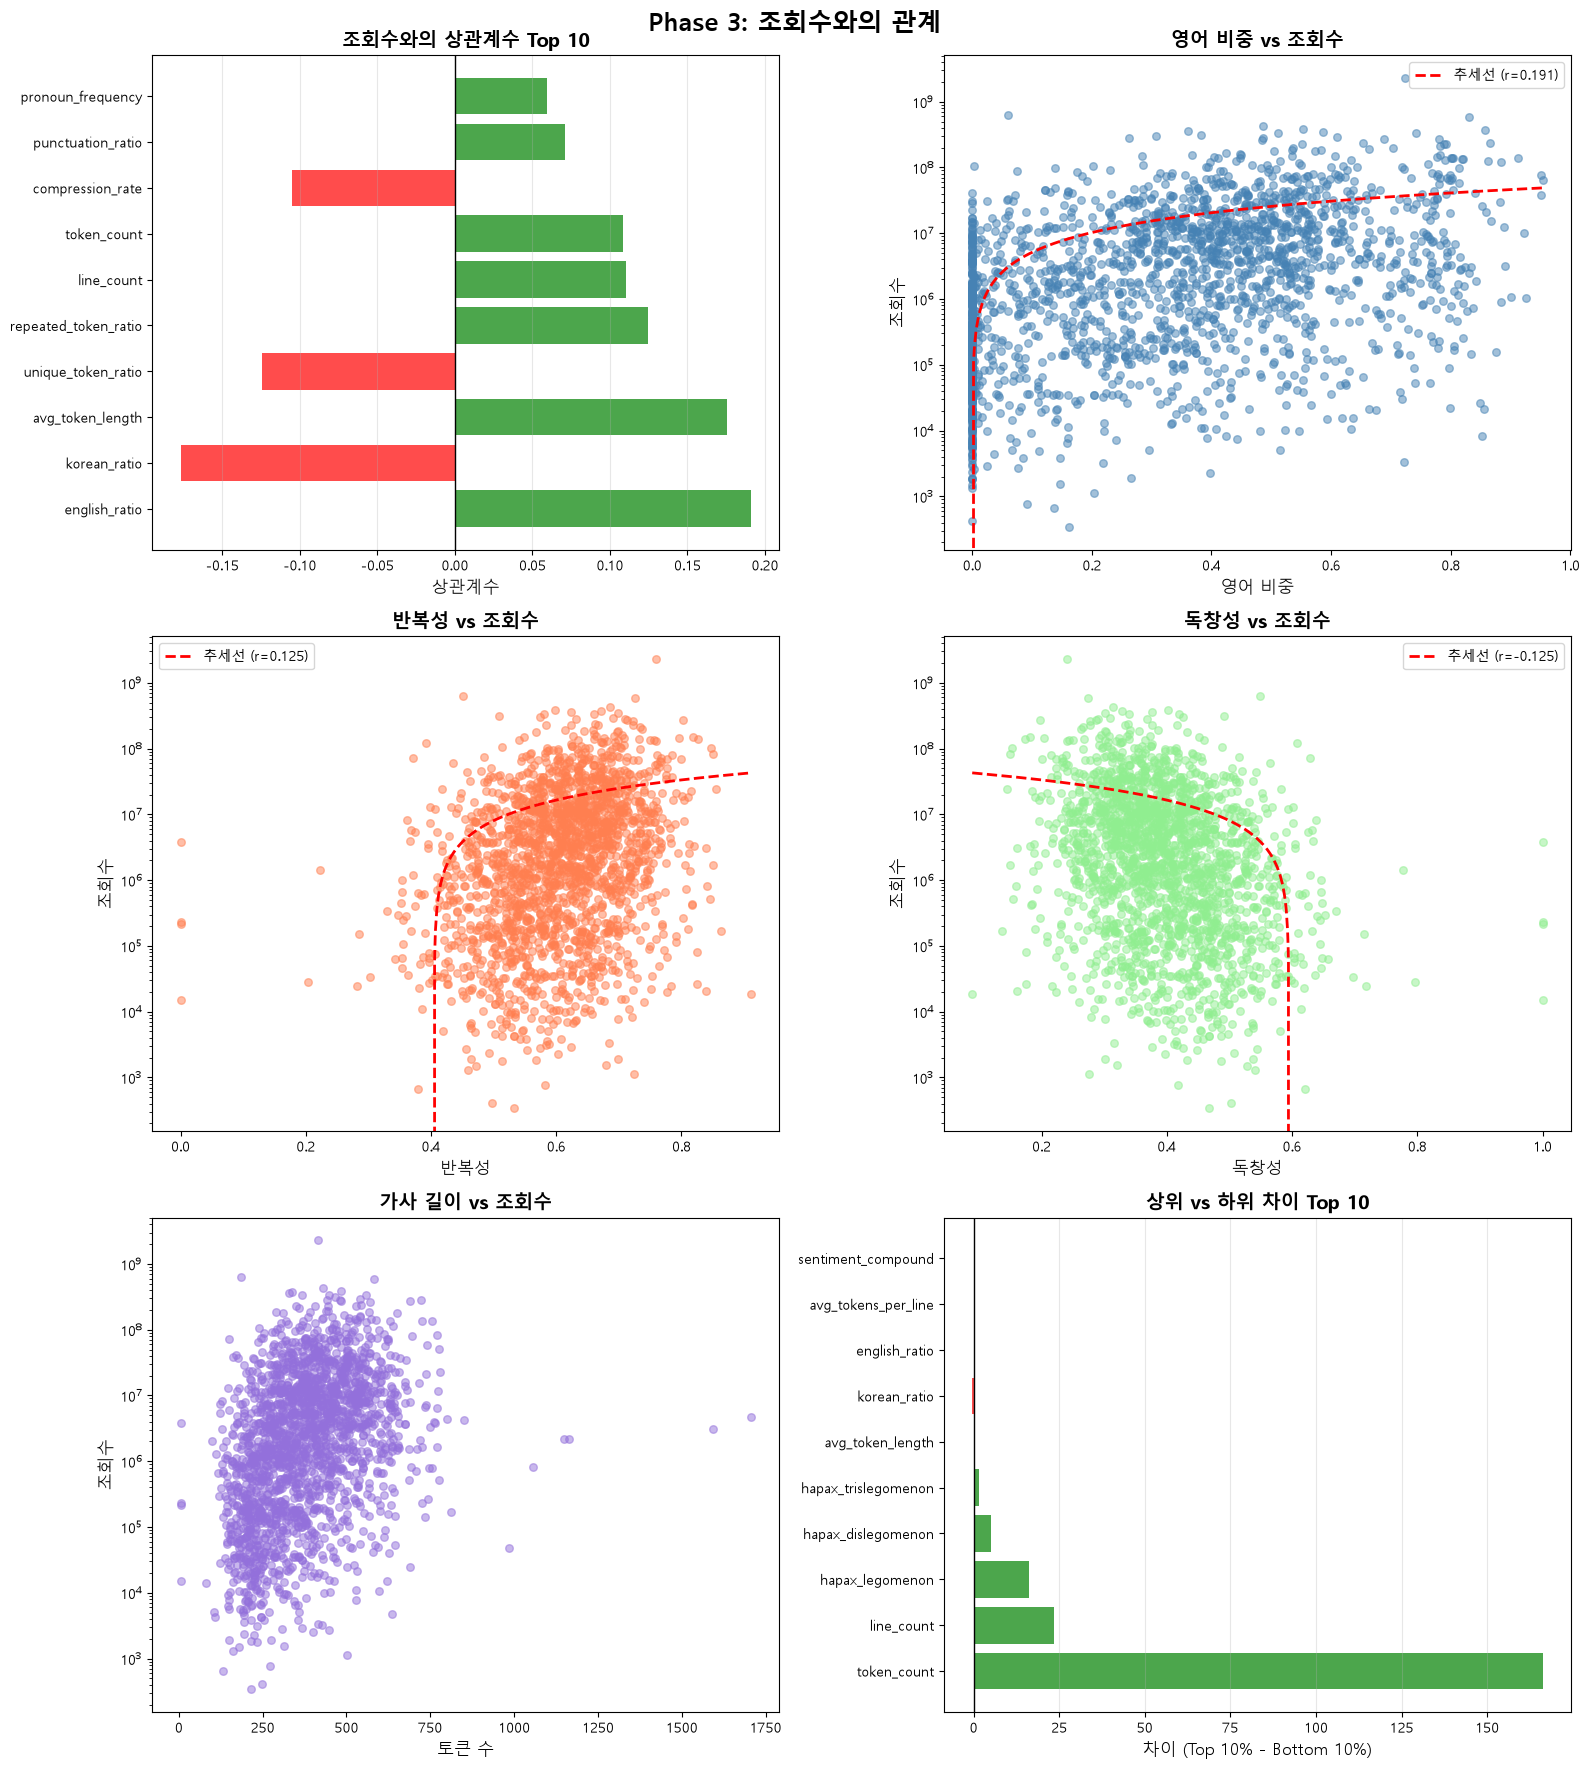

In [9]:
# ============================================
# PHASE 3: 타겟 변수와의 관계
# ============================================

print("\n" + "="*100)
print("PHASE 3: 타겟 변수(조회수)와의 관계")
print("="*100)

# 3.1 상관관계 분석
print("\n[3.1 상관관계 분석]")
correlations = []
for feature in lyrics_features:
    corr, pval = pearsonr(df_final[feature], df_final['api_view_count'])
    correlations.append({
        '변수': feature,
        '상관계수': corr,
        'p-value': pval,
        '유의함': 'Yes' if pval < 0.05 else 'No',
        '효과크기': 'Large' if abs(corr) > 0.5 else 'Medium' if abs(corr) > 0.3 else 'Small' if abs(corr) > 0.1 else 'Negligible'
    })

corr_df = pd.DataFrame(correlations).sort_values('상관계수', key=abs, ascending=False)
print(corr_df.to_string())

# 3.2 조회수 구간별 분석
print("\n[3.2 조회수 구간별 분석]")
quantiles = [0, 0.1, 0.25, 0.75, 0.9, 1.0]
labels = ['Bottom 10%', 'Low 25%', 'Middle 50%', 'Top 25%', 'Top 10%']
df_final['view_quantile'] = pd.qcut(df_final['api_view_count'], q=quantiles, labels=labels, duplicates='drop')

segment_analysis = df_final.groupby('view_quantile')[lyrics_features].mean()
print(segment_analysis.to_string())

# 상위 vs 하위 비교
top_10 = df_final[df_final['api_view_count'] >= df_final['api_view_count'].quantile(0.9)]
bottom_10 = df_final[df_final['api_view_count'] <= df_final['api_view_count'].quantile(0.1)]

comparison = []
for feature in lyrics_features:
    top_mean = top_10[feature].mean()
    bottom_mean = bottom_10[feature].mean()
    diff = top_mean - bottom_mean
    pct_change = (diff / bottom_mean * 100) if bottom_mean != 0 else 0

    # t-test
    t_stat, p_val = ttest_ind(top_10[feature].dropna(), bottom_10[feature].dropna())

    comparison.append({
        '변수': feature,
        'Top_10%': top_mean,
        'Bottom_10%': bottom_mean,
        '차이': diff,
        '변화율(%)': pct_change,
        't-statistic': t_stat,
        'p-value': p_val,
        '유의함': 'Yes' if p_val < 0.05 else 'No'
    })

comparison_df = pd.DataFrame(comparison).sort_values('차이', key=abs, ascending=False)
print("\n상위 10% vs 하위 10% 비교:")
print(comparison_df.to_string())

# Phase 3 시각화
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Phase 3: 조회수와의 관계', fontsize=18, fontweight='bold')

# 1. 상관계수 Top 10
ax1 = axes[0, 0]
top_corr = corr_df.head(10)
colors = ['green' if x > 0 else 'red' for x in top_corr['상관계수']]
bars = ax1.barh(range(len(top_corr)), top_corr['상관계수'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(top_corr)))
ax1.set_yticklabels(top_corr['변수'], fontsize=10)
ax1.set_xlabel('상관계수', fontsize=12)
ax1.set_title('조회수와의 상관계수 Top 10', fontsize=14, fontweight='bold')
ax1.axvline(0, color='black', linestyle='-', linewidth=1)
ax1.grid(axis='x', alpha=0.3)

# 2. 영어 비중 vs 조회수
ax2 = axes[0, 1]
ax2.scatter(df_final['english_ratio'], df_final['api_view_count'],
           alpha=0.5, s=30, c='steelblue')
z = np.polyfit(df_final['english_ratio'], df_final['api_view_count'], 1)
p = np.poly1d(z)
ax2.plot(df_final['english_ratio'].sort_values(), p(df_final['english_ratio'].sort_values()),
        "r--", linewidth=2, label=f'추세선 (r={corr_df[corr_df["변수"]=="english_ratio"]["상관계수"].values[0]:.3f})')
ax2.set_xlabel('영어 비중', fontsize=12)
ax2.set_ylabel('조회수', fontsize=12)
ax2.set_title('영어 비중 vs 조회수', fontsize=14, fontweight='bold')
ax2.legend()
ax2.set_yscale('log')

# 3. 반복성 vs 조회수
ax3 = axes[1, 0]
ax3.scatter(df_final['repeated_token_ratio'], df_final['api_view_count'],
           alpha=0.5, s=30, c='coral')
z = np.polyfit(df_final['repeated_token_ratio'], df_final['api_view_count'], 1)
p = np.poly1d(z)
ax3.plot(df_final['repeated_token_ratio'].sort_values(), p(df_final['repeated_token_ratio'].sort_values()),
        "r--", linewidth=2, label=f'추세선 (r={corr_df[corr_df["변수"]=="repeated_token_ratio"]["상관계수"].values[0]:.3f})')
ax3.set_xlabel('반복성', fontsize=12)
ax3.set_ylabel('조회수', fontsize=12)
ax3.set_title('반복성 vs 조회수', fontsize=14, fontweight='bold')
ax3.legend()
ax3.set_yscale('log')

# 4. 독창성 vs 조회수
ax4 = axes[1, 1]
ax4.scatter(df_final['unique_token_ratio'], df_final['api_view_count'],
           alpha=0.5, s=30, c='lightgreen')
z = np.polyfit(df_final['unique_token_ratio'], df_final['api_view_count'], 1)
p = np.poly1d(z)
ax4.plot(df_final['unique_token_ratio'].sort_values(), p(df_final['unique_token_ratio'].sort_values()),
        "r--", linewidth=2, label=f'추세선 (r={corr_df[corr_df["변수"]=="unique_token_ratio"]["상관계수"].values[0]:.3f})')
ax4.set_xlabel('독창성', fontsize=12)
ax4.set_ylabel('조회수', fontsize=12)
ax4.set_title('독창성 vs 조회수', fontsize=14, fontweight='bold')
ax4.legend()
ax4.set_yscale('log')

# 5. 토큰 수 vs 조회수
ax5 = axes[2, 0]
ax5.scatter(df_final['token_count'], df_final['api_view_count'],
           alpha=0.5, s=30, c='mediumpurple')
ax5.set_xlabel('토큰 수', fontsize=12)
ax5.set_ylabel('조회수', fontsize=12)
ax5.set_title('가사 길이 vs 조회수', fontsize=14, fontweight='bold')
ax5.set_yscale('log')

# 6. 상위 vs 하위 차이 Top 10
ax6 = axes[2, 1]
top_diff = comparison_df.head(10)
colors = ['green' if x > 0 else 'red' for x in top_diff['차이']]
bars = ax6.barh(range(len(top_diff)), top_diff['차이'], color=colors, alpha=0.7)
ax6.set_yticks(range(len(top_diff)))
ax6.set_yticklabels(top_diff['변수'], fontsize=10)
ax6.set_xlabel('차이 (Top 10% - Bottom 10%)', fontsize=12)
ax6.set_title('상위 vs 하위 차이 Top 10', fontsize=14, fontweight='bold')
ax6.axvline(0, color='black', linestyle='-', linewidth=1)
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 1-5. 전반적 EDA — Phase 4: 그룹 비교
장르 등 그룹별로 변수들을 비교(ANOVA 등 통계 검정 포함)합니다.


PHASE 4: 그룹별 비교 분석

[4.1 장르별 가사 특성]
             sentiment_compound  sentiment_positive  sentiment_negative  sentiment_neutral  token_count  unique_token_ratio  repeated_token_ratio  avg_token_length  hapax_legomenon  hapax_dislegomenon  hapax_trislegomenon  line_count  avg_tokens_per_line  unique_tokens_per_line  punctuation_ratio  compression_rate  pronoun_frequency  korean_ratio  english_ratio  api_view_count
genie_genre                                                                                                                                                                                                                                                                                                                                                                                
팝                      0.241410            0.475905            0.234495           0.365040   498.250000            0.268845              0.731155          2.933500        62.350000           24.750000   

                        변수       F-통계량        p-value  유의함
17            korean_ratio  173.891813  5.920813e-202  Yes
18           english_ratio  158.345794  5.549652e-187  Yes
4              token_count  151.133570  7.325885e-180  Yes
11              line_count  136.028571  1.435154e-164  Yes
7         avg_token_length  109.137345  5.583320e-136  Yes
14       punctuation_ratio   67.086737   2.736796e-87  Yes
8          hapax_legomenon   66.849672   5.333206e-87  Yes
6     repeated_token_ratio   66.761214   6.841480e-87  Yes
5       unique_token_ratio   66.761101   6.843654e-87  Yes
9       hapax_dislegomenon   21.999370   7.889686e-29  Yes
12     avg_tokens_per_line   15.563543   5.480514e-20  Yes
10     hapax_trislegomenon   14.970097   3.601990e-19  Yes
13  unique_tokens_per_line   12.873448   2.785276e-16  Yes
15        compression_rate   11.918716   5.733483e-15  Yes
16       pronoun_frequency    7.426144   7.689695e-09  Yes
1       sentiment_positive    7.337509   1.011808e-08  Y

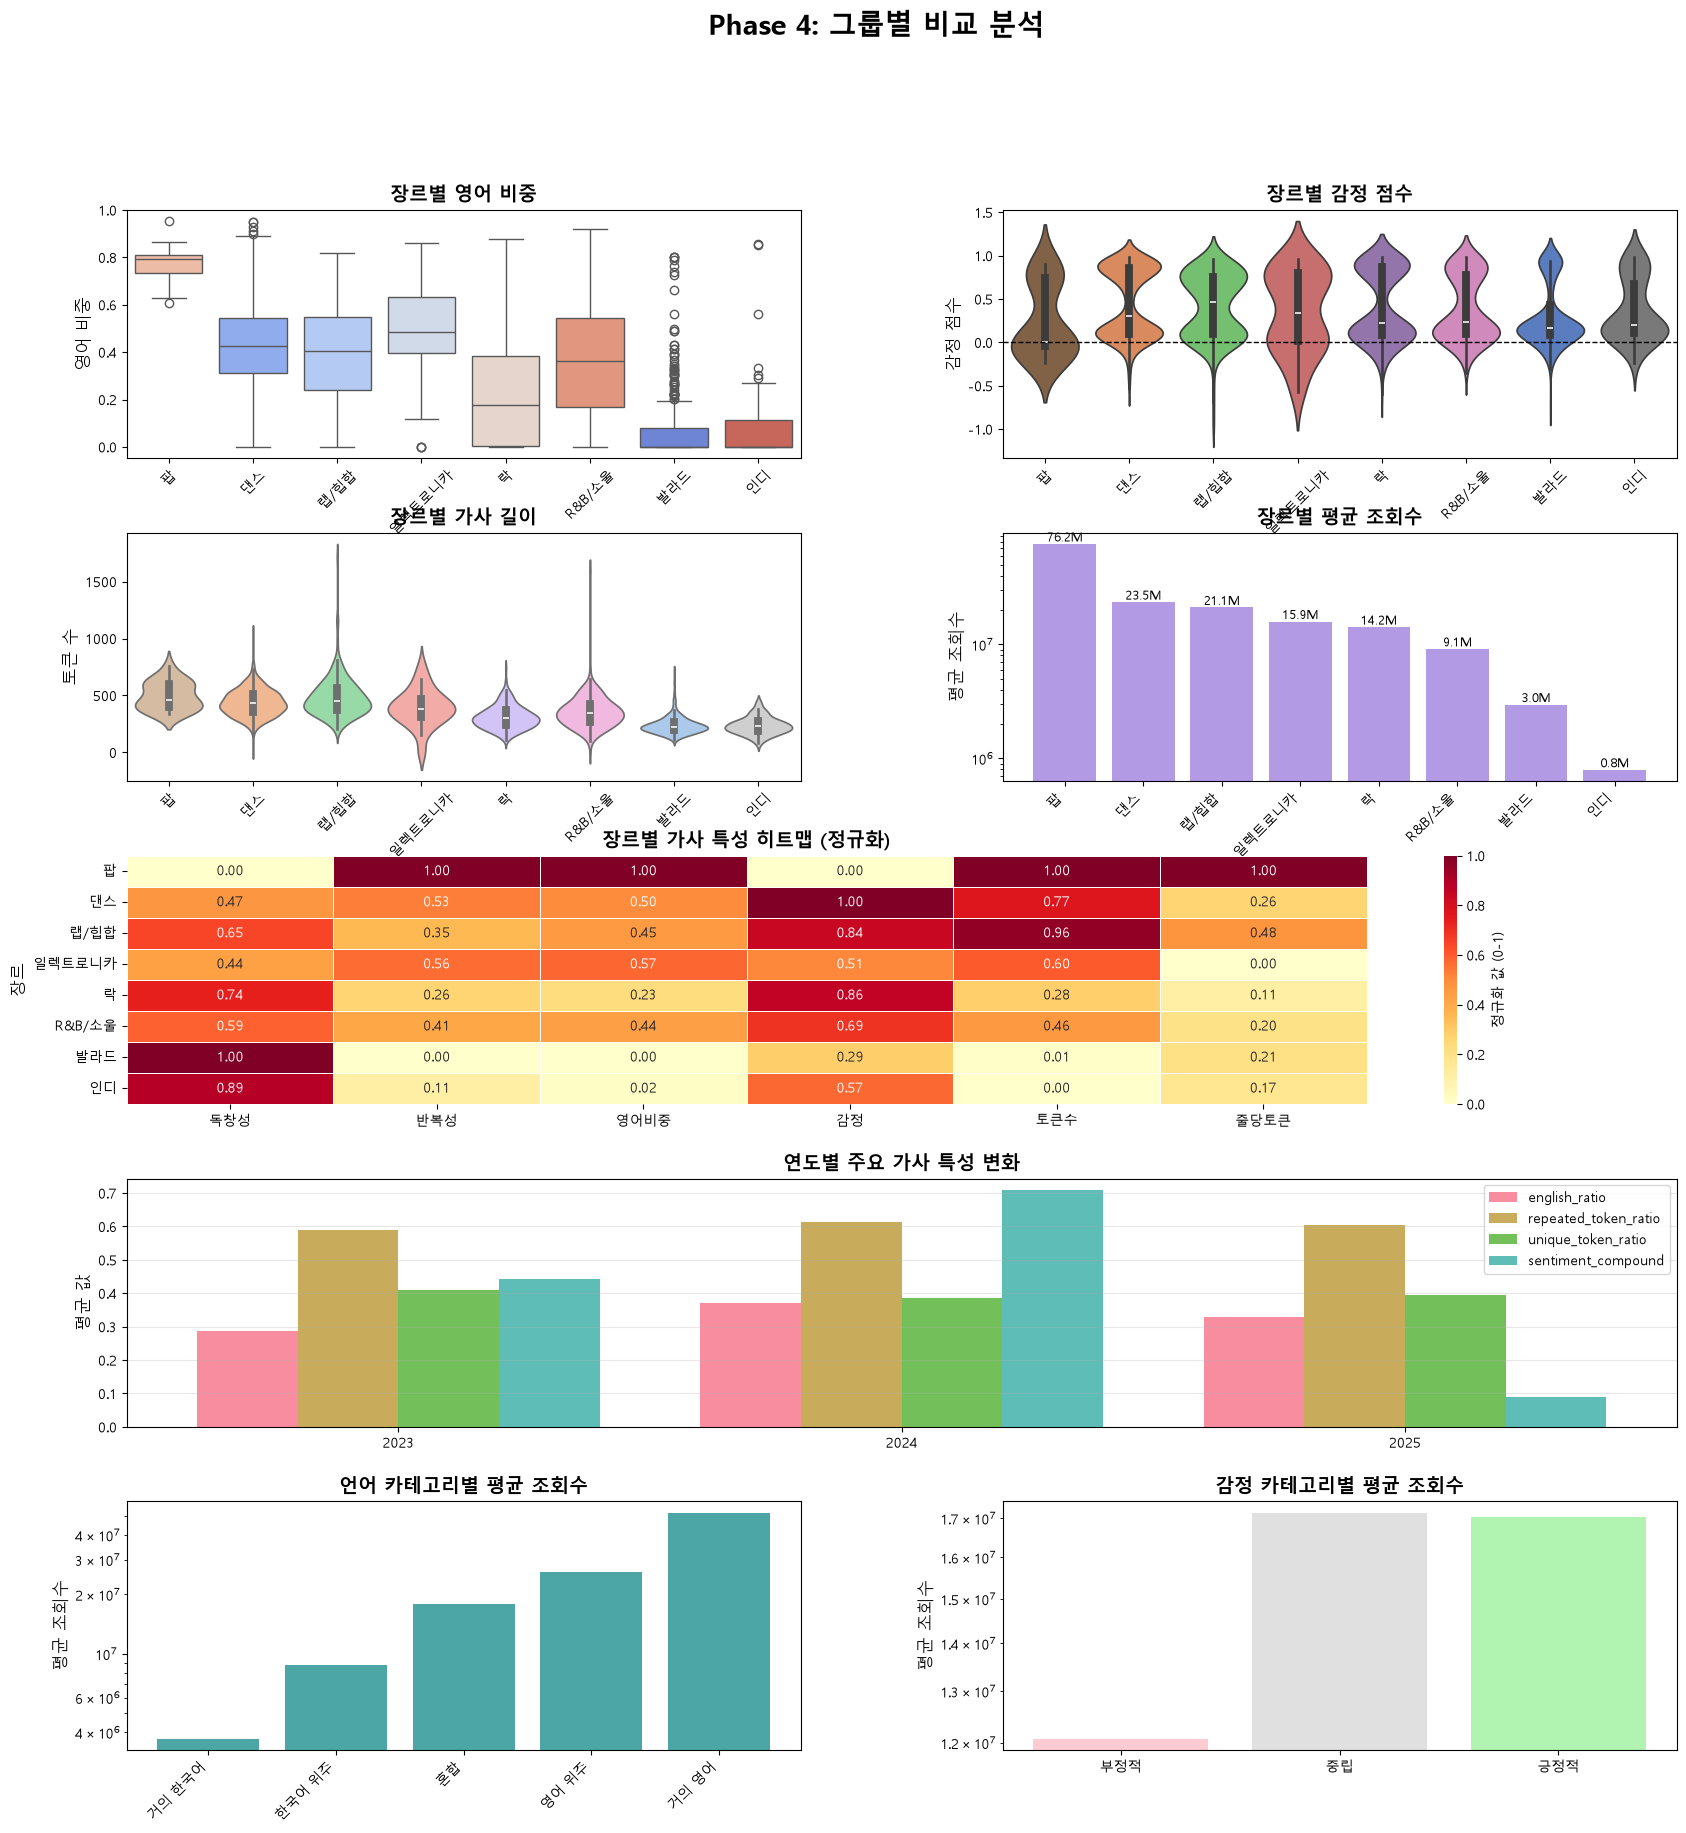

In [10]:
# ============================================
# PHASE 4: 그룹별 비교 분석
# ============================================

print("\n" + "="*100)
print("PHASE 4: 그룹별 비교 분석")
print("="*100)

# 4.1 장르별 가사 특성
print("\n[4.1 장르별 가사 특성]")
genre_profile = df_final.groupby('genie_genre')[lyrics_features + ['api_view_count']].mean()
genre_profile = genre_profile.sort_values('api_view_count', ascending=False)
print(genre_profile.to_string())

# 장르별 ANOVA
print("\n장르 간 차이 검정 (ANOVA):")
anova_results = []
for feature in lyrics_features:
    groups = [df_final[df_final['genie_genre'] == g][feature].dropna()
              for g in df_final['genie_genre'].unique()]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({
        '변수': feature,
        'F-통계량': f_stat,
        'p-value': p_val,
        '유의함': 'Yes' if p_val < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results).sort_values('F-통계량', ascending=False)
print(anova_df.to_string())

# 4.2 연도별 트렌드
print("\n[4.2 연도별 트렌드 (2023~2025)]")
year_comparison = df_final.groupby('year')[lyrics_features + ['api_view_count']].mean()
print(year_comparison.T.to_string())

# 변화율 계산
if len(year_comparison) >= 2:
    years = sorted(df_final['year'].unique())
    change_pct = ((year_comparison.loc[years[-1]] - year_comparison.loc[years[0]]) /
                  year_comparison.loc[years[0]] * 100)
    print(f"\n{years[0]}년 대비 {years[-1]}년 변화율(%):")
    print(change_pct.sort_values(ascending=False).to_string())

# Phase 4 시각화
fig = plt.figure(figsize=(20, 20))
gs = fig.add_gridspec(5, 2, hspace=0.3, wspace=0.3)
fig.suptitle('Phase 4: 그룹별 비교 분석', fontsize=20, fontweight='bold')

genres = genre_profile.index.tolist()

# 3. 장르별 영어 비중
ax3 = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df_final, x='genie_genre', y='english_ratio',
            order=genres, ax=ax3, hue='genie_genre', legend=False, palette='coolwarm')
ax3.set_xlabel('')
ax3.set_ylabel('영어 비중', fontsize=12)
ax3.set_title('장르별 영어 비중', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# 4. 장르별 감정 점수
ax4 = fig.add_subplot(gs[0, 1])
sns.violinplot(data=df_final, x='genie_genre', y='sentiment_compound',
              order=genres, ax=ax4, hue='genie_genre', legend=False, palette='muted')
ax4.axhline(0, color='black', linestyle='--', linewidth=1)
ax4.set_xlabel('')
ax4.set_ylabel('감정 점수', fontsize=12)
ax4.set_title('장르별 감정 점수', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# 5. 장르별 토큰 수
ax5 = fig.add_subplot(gs[1, 0])
sns.violinplot(data=df_final, x='genie_genre', y='token_count',
              order=genres, ax=ax5, hue='genie_genre', legend=False, palette='pastel')
ax5.set_xlabel('')
ax5.set_ylabel('토큰 수', fontsize=12)
ax5.set_title('장르별 가사 길이', fontsize=14, fontweight='bold')
ax5.tick_params(axis='x', rotation=45)

# 6. 장르별 평균 조회수
ax6 = fig.add_subplot(gs[1, 1])
avg_views_by_genre = df_final.groupby('genie_genre')['api_view_count'].mean().loc[genres]
bars = ax6.bar(range(len(genres)), avg_views_by_genre.values, color='mediumpurple', alpha=0.7)
ax6.set_xticks(range(len(genres)))
ax6.set_xticklabels(genres, rotation=45, ha='right')
ax6.set_ylabel('평균 조회수', fontsize=12)
ax6.set_title('장르별 평균 조회수', fontsize=14, fontweight='bold')
ax6.set_yscale('log')
for i, (bar, val) in enumerate(zip(bars, avg_views_by_genre.values)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

# 7. 장르별 히트맵 (정규화)
ax7 = fig.add_subplot(gs[2, :])
scaler = MinMaxScaler()
heatmap_data = genre_profile[['unique_token_ratio', 'repeated_token_ratio',
                               'english_ratio', 'sentiment_compound',
                               'token_count', 'avg_tokens_per_line']]
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=['독창성', '반복성', '영어비중', '감정', '토큰수', '줄당토큰']
)
sns.heatmap(heatmap_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax7, cbar_kws={'label': '정규화 값 (0-1)'})
ax7.set_title('장르별 가사 특성 히트맵 (정규화)', fontsize=14, fontweight='bold')
ax7.set_ylabel('장르', fontsize=12)

# 8. 연도별 트렌드 (주요 변수)
if len(df_final['year'].unique()) > 1:
    ax8 = fig.add_subplot(gs[3, :])
    trend_vars = ['english_ratio', 'repeated_token_ratio', 'unique_token_ratio', 'sentiment_compound']
    year_trend = df_final.groupby('year')[trend_vars].mean()

    x = range(len(year_trend))
    width = 0.2

    for i, var in enumerate(trend_vars):
        ax8.bar([p + width*i for p in x], year_trend[var], width,
               label=var, alpha=0.8)

    ax8.set_xticks([p + width*1.5 for p in x])
    ax8.set_xticklabels(year_trend.index)
    ax8.set_ylabel('평균 값', fontsize=12)
    ax8.set_title('연도별 주요 가사 특성 변화', fontsize=14, fontweight='bold')
    ax8.legend(loc='best')
    ax8.grid(axis='y', alpha=0.3)

# 9. 언어 카테고리별 평균 조회수
ax9 = fig.add_subplot(gs[4, 0])
lang_cat_views = df_final.groupby('language_category')['api_view_count'].mean()
bars = ax9.bar(range(len(lang_cat_views)), lang_cat_views.values, color='teal', alpha=0.7)
ax9.set_xticks(range(len(lang_cat_views)))
ax9.set_xticklabels(lang_cat_views.index, rotation=45, ha='right')
ax9.set_ylabel('평균 조회수', fontsize=12)
ax9.set_title('언어 카테고리별 평균 조회수', fontsize=14, fontweight='bold')
ax9.set_yscale('log')

# 10. 감정 카테고리별 평균 조회수
ax10 = fig.add_subplot(gs[4, 1])
emotion_cat_views = df_final.groupby('emotion_category')['api_view_count'].mean()
bars = ax10.bar(range(len(emotion_cat_views)), emotion_cat_views.values,
               color=['#FFB6C1', '#D3D3D3', '#90EE90'], alpha=0.7)
ax10.set_xticks(range(len(emotion_cat_views)))
ax10.set_xticklabels(emotion_cat_views.index)
ax10.set_ylabel('평균 조회수', fontsize=12)
ax10.set_title('감정 카테고리별 평균 조회수', fontsize=14, fontweight='bold')
ax10.set_yscale('log')

plt.show()

### 1-6. 전반적 EDA — Phase 5: 패턴 발견
변수 간 군집·패턴을 탐색해 흥미로운 조합을 찾습니다.


PHASE 5: 패턴 및 특이점 발견

[5.1 극단값 케이스 스터디]

가장 긴 가사 Top 5:
                                            songName                                                                                                                                                                                                               artists  token_count  api_view_count genie_genre
1772                                           FASHO  1117|박재범|JayPark|1,1174|김하온 (HAON)|HAON|1,1191|식케이 (Sik-K)|Sik-K|1,1210|pH-1|pH-1|1,1431|그루비룸 (GroovyRoom)|GroovyRoom|1,1565|Woodie Gochild|woodiegochild|1,1732|BIG Naughty (서동현)|BIGNaughty|1,3000|릴보이 (lIlBOI)||0         1706       4669793.0        랩/힙합
80    Around the world in a day (feat. Moses Sumney)                                                                                                                                                                                                           404|RM|RM|1         1593       3076332.0      R&B/소울
414             Smo


클러스터별 특성:

클러스터별 곡 수:
cluster
0    450
1    539
2    563
3    490

클러스터별 평균 특성:
         unique_token_ratio  repeated_token_ratio  english_ratio  sentiment_compound  token_count  avg_tokens_per_line  api_view_count
cluster                                                                                                                               
0                  0.524745              0.475255       0.071070            0.264075   231.471111             5.569044    4.512365e+06
1                  0.397459              0.602541       0.335278            0.854071   381.816327             5.445380    1.514242e+07
2                  0.385588              0.614412       0.281873            0.101302   360.371226             5.320124    1.261976e+07
3                  0.292642              0.707358       0.601823            0.392696   523.234694             6.450082    3.443077e+07


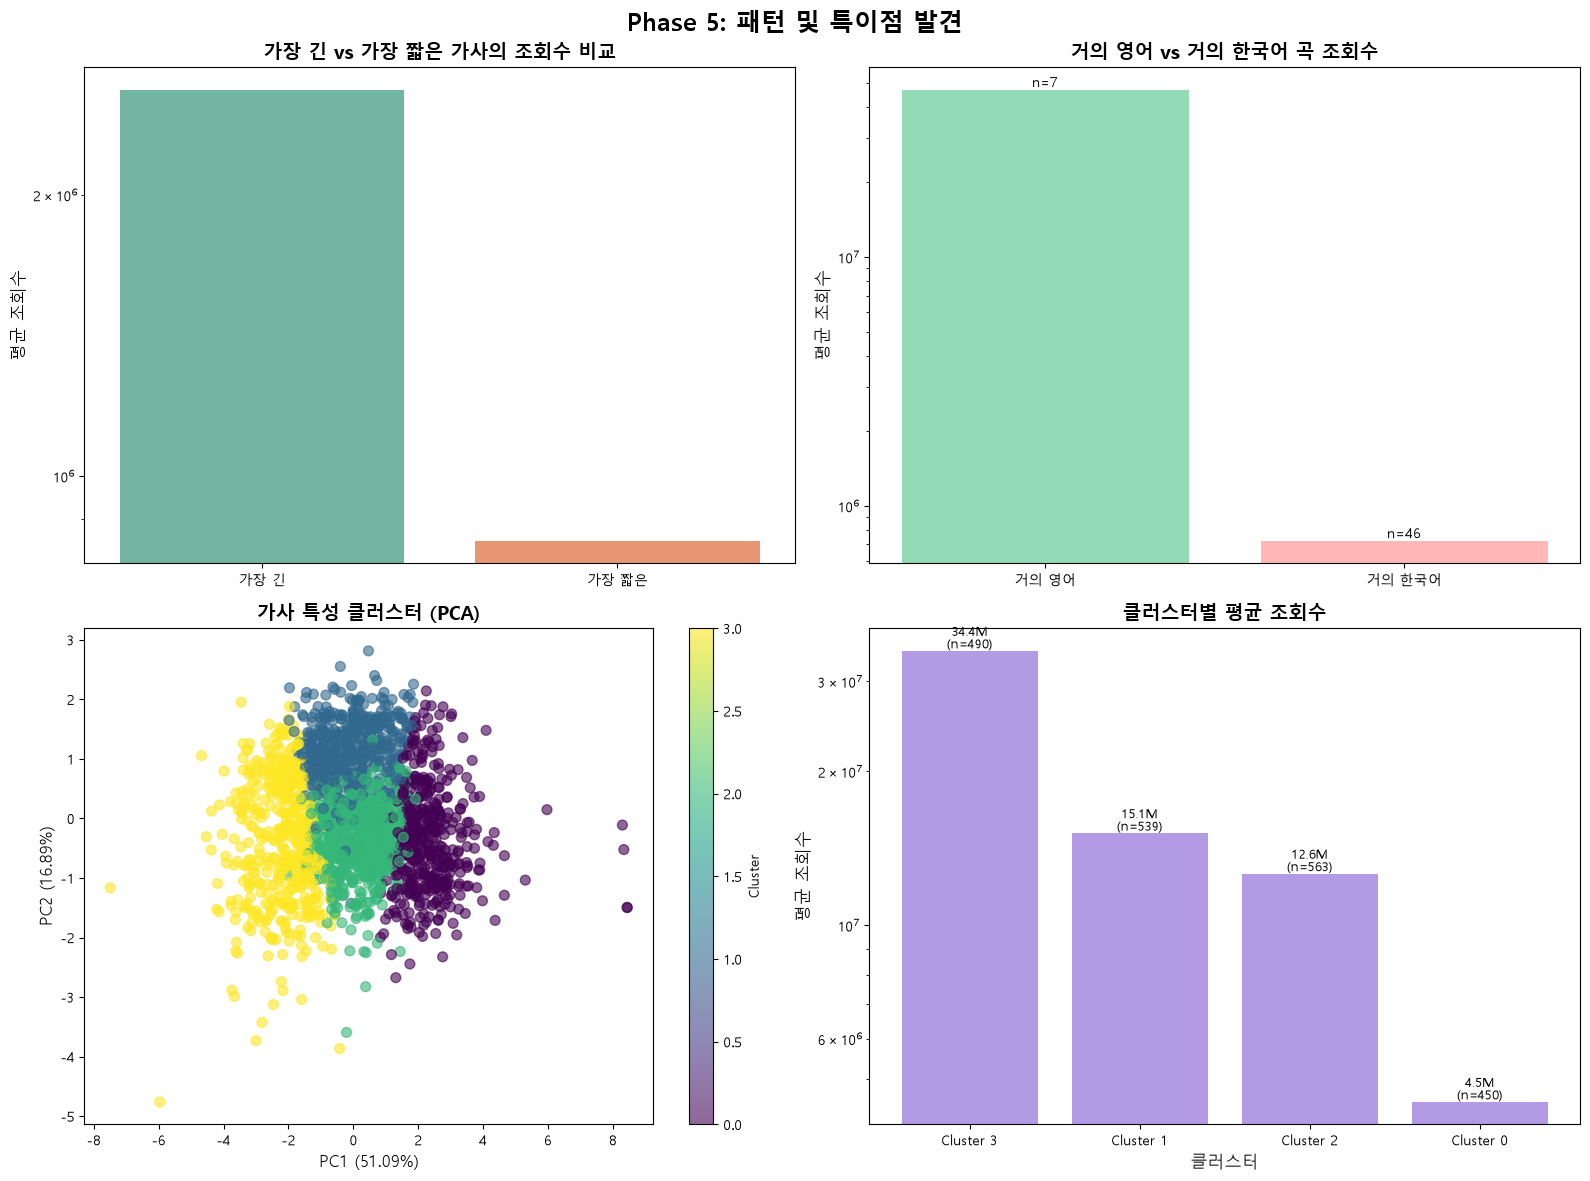


✅ Phase 5 완료!


In [11]:
# ============================================
# PHASE 5: 패턴 및 특이점 발견
# ============================================

print("\n" + "="*100)
print("PHASE 5: 패턴 및 특이점 발견")
print("="*100)

# 5.1 극단값 케이스
print("\n[5.1 극단값 케이스 스터디]")

# 가장 긴/짧은 가사
longest = df_final.nlargest(5, 'token_count')[['songName', 'artists', 'token_count', 'api_view_count', 'genie_genre']]
shortest = df_final.nsmallest(5, 'token_count')[['songName', 'artists', 'token_count', 'api_view_count', 'genie_genre']]
print("\n가장 긴 가사 Top 5:")
print(longest.to_string())
print("\n가장 짧은 가사 Top 5:")
print(shortest.to_string())

# 100% 영어 vs 100% 한국어
pure_english = df_final[df_final['english_ratio'] > 0.9][['songName', 'artists', 'english_ratio', 'api_view_count', 'genie_genre']]
pure_korean = df_final[df_final['korean_ratio'] > 0.9][['songName', 'artists', 'korean_ratio', 'api_view_count', 'genie_genre']]
print(f"\n거의 100% 영어 곡 ({len(pure_english)}곡):")
if len(pure_english) > 0:
    print(pure_english.head(10).to_string())
    print(f"평균 조회수: {pure_english['api_view_count'].mean():,.0f}")
print(f"\n거의 100% 한국어 곡 ({len(pure_korean)}곡):")
if len(pure_korean) > 0:
    print(pure_korean.head(10).to_string())
    print(f"평균 조회수: {pure_korean['api_view_count'].mean():,.0f}")

# 가장 독창적 vs 가장 반복적
most_unique = df_final.nlargest(5, 'unique_token_ratio')[['songName', 'artists', 'unique_token_ratio', 'api_view_count', 'genie_genre']]
most_repetitive = df_final.nsmallest(5, 'unique_token_ratio')[['songName', 'artists', 'unique_token_ratio', 'repeated_token_ratio', 'api_view_count', 'genie_genre']]
print("\n가장 독창적인 가사 Top 5:")
print(most_unique.to_string())
print("\n가장 반복적인 가사 Top 5:")
print(most_repetitive.to_string())

# 5.2 "예상 밖" 케이스
print("\n[5.2 예상 밖 케이스]")

# 복잡한데 대박 (상위 25% 조회수 & 상위 25% 복잡도)
view_threshold_high = df_final['api_view_count'].quantile(0.75)
unique_threshold_high = df_final['unique_token_ratio'].quantile(0.75)
complex_hit = df_final[(df_final['api_view_count'] > view_threshold_high) &
                       (df_final['unique_token_ratio'] > unique_threshold_high)]
print(f"\n복잡한데 대박 난 곡 ({len(complex_hit)}곡):")
if len(complex_hit) > 0:
    print(complex_hit[['songName', 'artists', 'unique_token_ratio', 'api_view_count', 'genie_genre']].head(10).to_string())

# 단순한데 망함 (하위 25% 조회수 & 하위 25% 독창성)
view_threshold_low = df_final['api_view_count'].quantile(0.25)
unique_threshold_low = df_final['unique_token_ratio'].quantile(0.25)
simple_flop = df_final[(df_final['api_view_count'] < view_threshold_low) &
                       (df_final['unique_token_ratio'] < unique_threshold_low)]
print(f"\n단순한데 망한 곡 ({len(simple_flop)}곡):")
if len(simple_flop) > 0:
    print(simple_flop[['songName', 'artists', 'unique_token_ratio', 'api_view_count', 'genie_genre']].head(10).to_string())

# 영어 적은데 글로벌 히트 (상위 10% 조회수 & 영어 < 30%)
english_threshold = 0.3
global_hit_korean = df_final[(df_final['api_view_count'] > df_final['api_view_count'].quantile(0.9)) &
                             (df_final['english_ratio'] < english_threshold)]
print(f"\n영어 적은데 글로벌 히트 ({len(global_hit_korean)}곡):")
if len(global_hit_korean) > 0:
    print(global_hit_korean[['songName', 'artists', 'english_ratio', 'korean_ratio', 'api_view_count', 'genie_genre']].to_string())

# 5.3 클러스터링
print("\n[5.3 가사 특성 기반 클러스터링]")

# K-means 클러스터링 (k=4)
cluster_features = ['unique_token_ratio', 'repeated_token_ratio', 'english_ratio',
                   'sentiment_compound', 'token_count', 'avg_tokens_per_line']
X = df_final[cluster_features].fillna(df_final[cluster_features].mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_scaled)

print("\n클러스터별 특성:")
cluster_profile = df_final.groupby('cluster')[cluster_features + ['api_view_count']].mean()
cluster_counts = df_final['cluster'].value_counts().sort_index()
print("\n클러스터별 곡 수:")
print(cluster_counts.to_string())
print("\n클러스터별 평균 특성:")
print(cluster_profile.to_string())

# Phase 5 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phase 5: 패턴 및 특이점 발견', fontsize=18, fontweight='bold')

# 1. 극단값 비교 (길이)
ax1 = axes[0, 0]
extreme_length = pd.concat([
    longest.assign(category='가장 긴'),
    shortest.assign(category='가장 짧은')
])
sns.barplot(data=extreme_length, x='category', y='api_view_count', ax=ax1,
           palette='Set2', errorbar=None)
ax1.set_ylabel('평균 조회수', fontsize=12)
ax1.set_xlabel('')
ax1.set_title('가장 긴 vs 가장 짧은 가사의 조회수 비교', fontsize=14, fontweight='bold')
ax1.set_yscale('log')

# 2. 100% 영어 vs 100% 한국어
ax2 = axes[0, 1]
lang_comparison = pd.DataFrame({
    'category': ['거의 영어', '거의 한국어'],
    'avg_views': [pure_english['api_view_count'].mean() if len(pure_english) > 0 else 0,
                  pure_korean['api_view_count'].mean() if len(pure_korean) > 0 else 0],
    'count': [len(pure_english), len(pure_korean)]
})
bars = ax2.bar(lang_comparison['category'], lang_comparison['avg_views'],
              color=['#66CC99', '#FF9999'], alpha=0.7)
ax2.set_ylabel('평균 조회수', fontsize=12)
ax2.set_xlabel('')
ax2.set_title('거의 영어 vs 거의 한국어 곡 조회수', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
for bar, count in zip(bars, lang_comparison['count']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'n={count}', ha='center', va='bottom', fontsize=10)

# 3. 클러스터 산점도 (PCA 2D)
ax3 = axes[1, 0]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
scatter = ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=df_final['cluster'],
                     cmap='viridis', alpha=0.6, s=50)
ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
ax3.set_title('가사 특성 클러스터 (PCA)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='Cluster')

# 4. 클러스터별 평균 조회수
ax4 = axes[1, 1]
cluster_views = df_final.groupby('cluster')['api_view_count'].mean().sort_values(ascending=False)
bars = ax4.bar(range(len(cluster_views)), cluster_views.values,
              color='mediumpurple', alpha=0.7)
ax4.set_xticks(range(len(cluster_views)))
ax4.set_xticklabels([f'Cluster {i}' for i in cluster_views.index])
ax4.set_ylabel('평균 조회수', fontsize=12)
ax4.set_xlabel('클러스터', fontsize=12)
ax4.set_title('클러스터별 평균 조회수', fontsize=14, fontweight='bold')
ax4.set_yscale('log')
for i, (bar, val) in enumerate(zip(bars, cluster_views.values)):
    height = bar.get_height()
    count = cluster_counts[cluster_views.index[i]]
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val/1e6:.1f}M\n(n={count})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Phase 5 완료!")

### 1-7. 가사 구조와 단순성 (Q2, Q5, Q8)

**분석**: 장르별 가사 독창성(Unique Token Ratio)과 반복성(Repeated Token Ratio)을 boxplot·t-test로 비교.
**결과**: 발라드는 독창성이 높고 반복성이 낮음(서사형 가사), 댄스는 반대로 독창성이 낮고 반복성이 매우 높음(후크 반복 중심) — 가설과 일치.

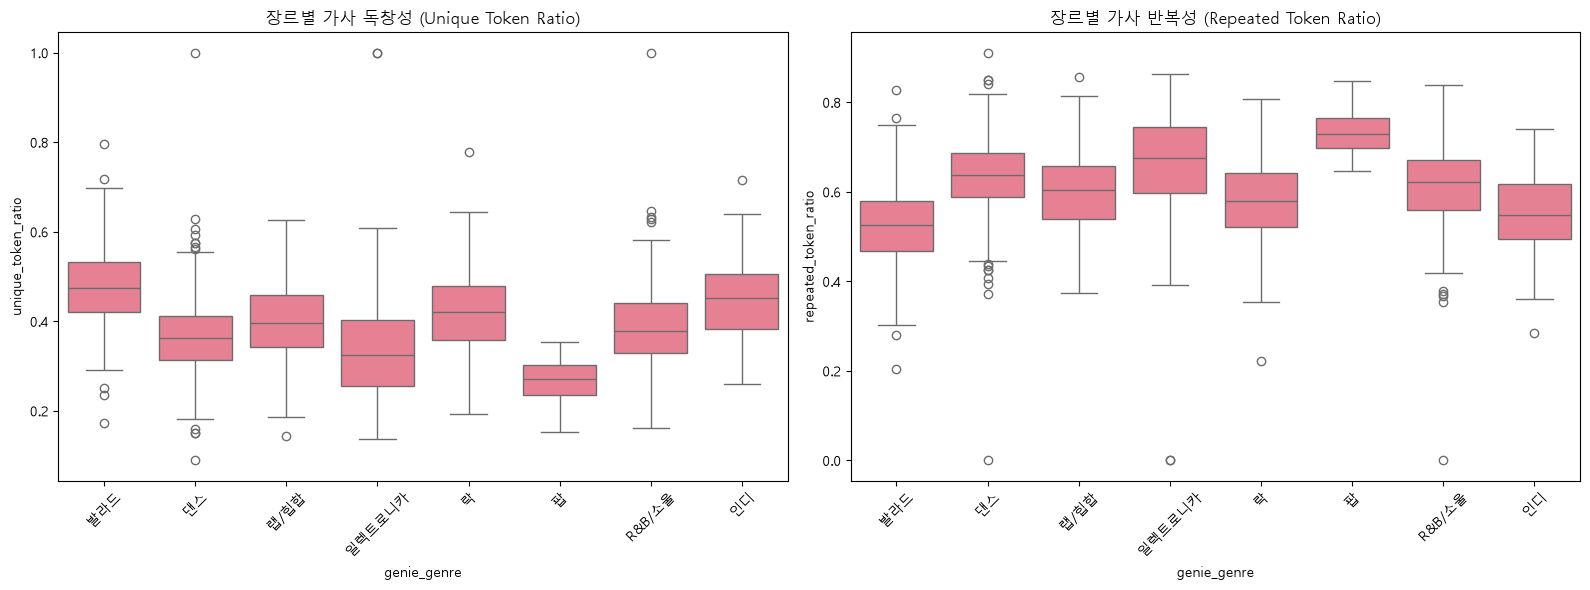

댄스 vs 발라드 반복성 차이 검정 P-value: 0.0000


In [12]:
# 2. 장르별 가사 복잡도(Unique Token Ratio)와 반복성(Repeated Token Ratio) 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='genie_genre', y='unique_token_ratio', data=df_final, ax=axes[0])
axes[0].set_title('장르별 가사 독창성 (Unique Token Ratio)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='genie_genre', y='repeated_token_ratio', data=df_final, ax=axes[1])
axes[1].set_title('장르별 가사 반복성 (Repeated Token Ratio)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 댄스 장르와 발라드 장르의 가사 단순성 비교 (T-test)
dance_rep = df_final[df_final['genie_genre'] == '댄스']['repeated_token_ratio']
ballad_rep = df_final[df_final['genie_genre'] == '발라드']['repeated_token_ratio']
t_stat, p_val = ttest_ind(dance_rep, ballad_rep)
print(f"댄스 vs 발라드 반복성 차이 검정 P-value: {p_val:.4f}")

### 1-8. 인기 요인과 2024년 트렌드 (Q4, Q7)

**분석**: 가사 독창성 상위 10% 그룹의 평균 조회수, 영어 비중과 조회수의 상관관계 확인.
**결과**: 독창적인 가사보다 오히려 '일반적/반복적인 가사'의 평균 조회수가 더 높음 → 지나친 독창성보다 친숙한 반복이 대중적 인기에 유리. 조회수 폭발 곡들은 영어 비중 50% 이상 구간에 많이 분포 → K-POP 글로벌화와 연결.
(영어 비중과 조회수의 관계 그래프는 1-4 Phase 3의 산점도로 확인합니다.)

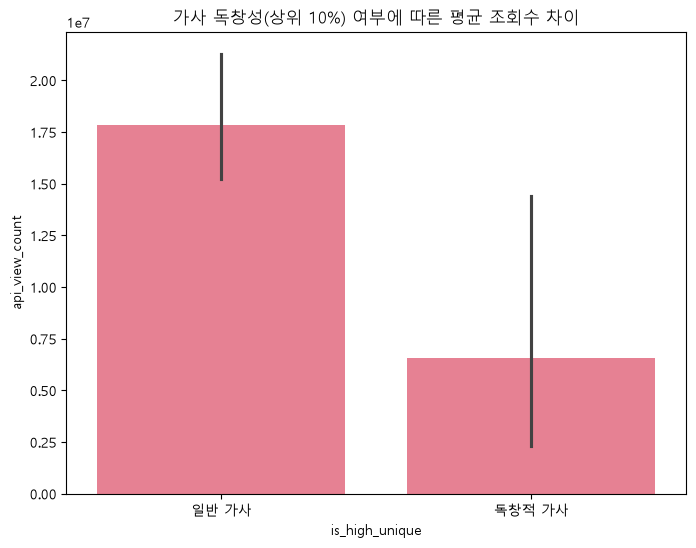

In [13]:
# 3. 가사 차별화와 인기(조회수)의 관계
# 독창성 상위 10%를 'High Unique' 그룹으로 분류
q_high = df_final['unique_token_ratio'].quantile(0.9)
df_final['is_high_unique'] = df_final['unique_token_ratio'] >= q_high

plt.figure(figsize=(8, 6))
sns.barplot(x='is_high_unique', y='api_view_count', data=df_final)
plt.title('가사 독창성(상위 10%) 여부에 따른 평균 조회수 차이')
plt.xticks([0, 1], ['일반 가사', '독창적 가사'])
plt.show()

### 1-9. 상위 1% 히트곡 비교

**분석**: 조회수 상위 1% '괴물 곡'과 일반 곡의 가사 반복성·영어 비중 비교.
**결과**: 상위 1% 곡은 영어 비중(0.57 vs 0.32)과 반복성(0.66 vs 0.60) 모두 일반 곡보다 높음 → 글로벌 지향 + 중독성 있는 반복 후크가 흥행 공식이라는 가설이 수치로 검증됨.

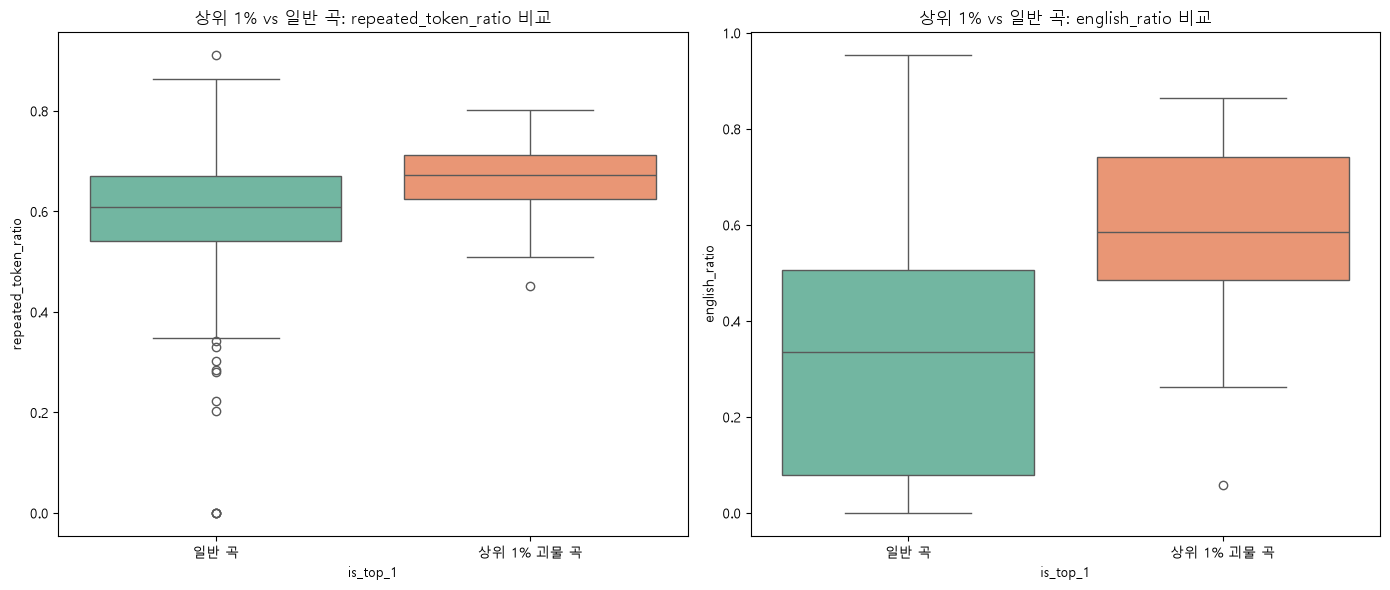

--- 그룹별 평균 비교 ---
          repeated_token_ratio  english_ratio
is_top_1                                     
False                 0.602322       0.323735
True                  0.660029       0.572148


In [14]:
# 상위 1% 기준값 설정
top_1_threshold = df_final['api_view_count'].quantile(0.99)
df_final['is_top_1'] = df_final['api_view_count'] >= top_1_threshold

# 시각화 데이터 준비
top_metrics = ['repeated_token_ratio', 'english_ratio']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, metric in enumerate(top_metrics):
    sns.boxplot(x='is_top_1', y=metric, data=df_final, ax=axes[i], palette="Set2")
    axes[i].set_title(f'상위 1% vs 일반 곡: {metric} 비교')
    axes[i].set_xticklabels(['일반 곡', '상위 1% 괴물 곡'])

plt.tight_layout()
plt.show()

# 실제 평균값 수치 확인
print("--- 그룹별 평균 비교 ---")
print(df_final.groupby('is_top_1')[top_metrics].mean())

### 1-10. 장르별 가사 복잡도 통합 지수

**분석**: `unique_token_ratio`, `avg_tokens_per_line`, `avg_token_length`를 0~1로 정규화 후 평균 내어 `lyrics_complexity_index`(가사 복잡도 통합 지수)를 만들고 장르별로 비교.
**결과**: 중앙값 기준 팝(0.41)·랩/힙합(0.33)이 복잡도 상위, 락·발라드(0.28)·인디(0.26)가 하위권이고 댄스(0.31)는 중간 수준.

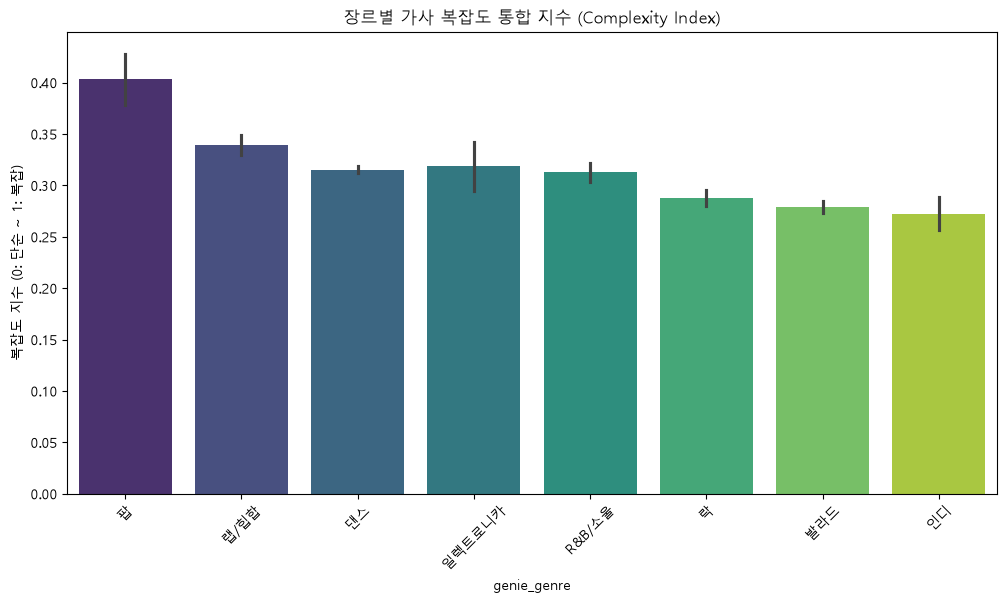

In [15]:
# 1. 지수화를 위한 스케일링 (0~1 사이로 변환)
scaler = MinMaxScaler()
cols_to_index = ['unique_token_ratio', 'avg_tokens_per_line', 'avg_token_length']
scaled_values = scaler.fit_transform(df_final[cols_to_index])

# 2. 통합 복잡도 지수 계산 (단순 평균)
df_final['lyrics_complexity_index'] = scaled_values.mean(axis=1)

# 3. 장르별 복잡도 시각화
plt.figure(figsize=(12, 6))
order = df_final.groupby('genie_genre')['lyrics_complexity_index'].median().sort_values(ascending=False).index
sns.barplot(x='genie_genre', y='lyrics_complexity_index', data=df_final, order=order, palette="viridis")

plt.title('장르별 가사 복잡도 통합 지수 (Complexity Index)')
plt.ylabel('복잡도 지수 (0: 단순 ~ 1: 복잡)')
plt.xticks(rotation=45)
plt.show()

In [16]:
# 장르별 복잡도 평균/중앙값 계산
genre_complexity = (
    df_final
    .groupby('genie_genre')['lyrics_complexity_index']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={
        'genie_genre': 'Genre',
        'mean': 'Avg_Complexity',
        'median': 'Median_Complexity',
        'count': 'Song_Count'
    })
    .sort_values(by='Median_Complexity', ascending=False)
)

genre_complexity

,Genre,Avg_Complexity,Median_Complexity,Song_Count
7,팝,0.403780,0.412769,20
3,랩/힙합,0.339089,0.333587,187
1,댄스,0.315288,0.313903,908
6,일렉트로니카,0.319320,0.305381,40
0,R&B/소울,0.313327,0.304005,212
2,락,0.287494,0.282539,259
4,발라드,0.279453,0.276587,356
5,인디,0.271713,0.264347,60


### 1-11. 특이 케이스 개요
장르 문법에서 벗어난 개별 곡 사례를 직접 확인합니다 (예: 발라드인데 너무 단순하거나, 댄스인데 너무 복잡한 경우).

**분석**: 장르 문법에서 벗어난 개별 곡 사례를 확인 — 발라드인데 복잡도가 매우 낮은 곡, 댄스인데 복잡도가 매우 높은 곡을 z-score로 찾고, 처음 살펴본 곡들의 가사 지표를 표로 확인합니다. (가사 원문은 싣지 않습니다.)
**대표 사례**: 발라드 저복잡도 - '366일', '사랑인걸', 'Miss You' 등 / 댄스 고복잡도 - 'Mantra'(제니), 'BADVILLAIN' 등(영어 가사 밀도·랩 비중이 높은 곡들).


🎵 발라드인데 unusually 단순한 곡
                       songName genie_genre  lyrics_complexity_index   z_score
1404                     꿈에 들어와         발라드                 0.103863 -3.194508
922                      매일 그대와         발라드                 0.118523 -2.927795
1534      혼자서 걸어요 (Prod. by 나얼)         발라드                 0.154889 -2.266188
1206  찬란한 겨울 (Beautiful Winter)         발라드                 0.157355 -2.221322
1258                   왜 이렇게 예뻐         발라드                 0.171387 -1.966048
504                       오랜만이야         발라드                 0.172327 -1.948946
1060                        스르륵         발라드                 0.172927 -1.938019
827              밤새 (Overnight)         발라드                 0.173359 -1.930163
737                       이별의 맛         발라드                 0.174612 -1.907378
1229                 너라는 꽃이 피었다         발라드                 0.183406 -1.747383

💃 댄스인데 unusually 복잡한 곡
                              songName genie_genre  lyrics_complexity_index  \
38 

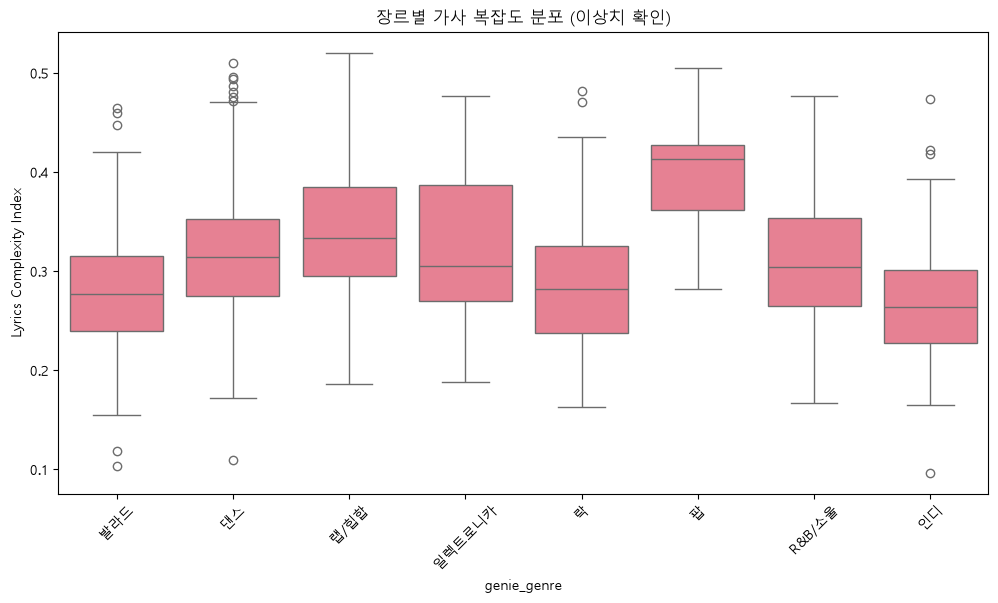

In [17]:
# 가사 복잡도 지수(lyrics_complexity_index)는 1-10에서 만든 값을 그대로 사용

# ================================
# 1. 장르별 복잡도 통계
# ================================
genre_stats = (
    df_final
    .groupby('genie_genre')['lyrics_complexity_index']
    .agg(['mean', 'std'])
    .reset_index()
)

# ================================
# 2. z-score 계산 (장르 평균에서 얼마나 벗어났는지)
# ================================
df_outlier = df_final.merge(genre_stats, on='genie_genre')

df_outlier['z_score'] = (
    (df_outlier['lyrics_complexity_index'] - df_outlier['mean'])
    / df_outlier['std']
)

# ================================
# 3. 특이 케이스 탐색
# ================================

# 🔹 발라드인데 너무 단순한 곡
simple_ballads = df_outlier[
    (df_outlier['genie_genre'] == '발라드') &
    (df_outlier['z_score'] < -1.5)
][['songName', 'genie_genre', 'lyrics_complexity_index', 'z_score']].sort_values('z_score')

# 🔹 댄스인데 너무 복잡한 곡
complex_dance = df_outlier[
    (df_outlier['genie_genre'] == '댄스') &
    (df_outlier['z_score'] > 1.5)
][['songName', 'genie_genre', 'lyrics_complexity_index', 'z_score']].sort_values('z_score', ascending=False)

print("\n🎵 발라드인데 unusually 단순한 곡")
print(simple_ballads.head(10))

print("\n💃 댄스인데 unusually 복잡한 곡")
print(complex_dance.head(10))

# ================================
# 4. 장르별 복잡도 분포 시각화
# ================================
plt.figure(figsize=(12,6))
sns.boxplot(data=df_final, x='genie_genre', y='lyrics_complexity_index')
plt.xticks(rotation=45)
plt.title("장르별 가사 복잡도 분포 (이상치 확인)")
plt.ylabel("Lyrics Complexity Index")
plt.show()

In [18]:
# 처음 분석에서 직접 살펴본 곡들의 가사 지표 (z_score는 위에서 계산한 장르 내 복잡도 z-score)
case_songs = {
    '발라드(단순한 편)': ['366일 (366 Days)', 'Miss You', '러브 레시피', '라떼 한 잔 (Feat. 이준혁 of 미래소년)'],
    '댄스(복잡한 편)': ['Mantra', 'BADVILLAIN', 'Could It Be', 'Algorithm',
                    'Broke My Heart (Feat. Lay Bankz)', 'Must Have Love',
                    'Nightwalker', 'Automatic', "Cherry Gene 'Baddest Mix'"],
}

rows = []
for group, songs in case_songs.items():
    for song in songs:
        found = df_outlier[df_outlier['songName'] == song]
        rows.append(found.assign(그룹=group) if not found.empty else pd.DataFrame({'songName': [song], '그룹': [group]}))
case_table = pd.concat(rows, ignore_index=True)

case_table[['그룹', 'songName', 'genie_genre', 'lyrics_complexity_index', 'z_score',
            'english_ratio', 'line_count', 'token_count', 'api_view_count']].round(3)

,그룹,songName,genie_genre,lyrics_complexity_index,z_score,english_ratio,line_count,token_count,api_view_count
0,발라드(단순한 편),366일 (366 Days),발라드,0.213,-1.218,0.038,39,210,2647844.0
1,발라드(단순한 편),Miss You,발라드,0.226,-0.970,0.217,48,207,1908353.0
2,발라드(단순한 편),러브 레시피,발라드,0.237,-0.776,0.297,50,306,56543.0
3,발라드(단순한 편),라떼 한 잔 (Feat. 이준혁 of 미래소년),발라드,0.204,-1.364,0.222,82,432,68565.0
4,댄스(복잡한 편),Mantra,댄스,0.429,1.996,0.788,80,529,229896119.0
5,댄스(복잡한 편),BADVILLAIN,댄스,0.510,3.421,0.592,53,426,51438283.0
6,댄스(복잡한 편),Could It Be,댄스,0.496,3.180,0.807,32,274,6814209.0
7,댄스(복잡한 편),Algorithm,댄스,0.361,0.804,0.401,59,329,12741977.0
8,댄스(복잡한 편),Broke My Heart (Feat. Lay Bankz),댄스,0.454,2.448,0.811,44,359,456707.0
9,댄스(복잡한 편),Must Have Love,댄스,0.347,0.556,0.090,38,277,21082541.0


### 1-12. 댄스 장르: 가사 복잡도-조회수 상관관계
**분석**: 댄스 장르만 필터링해 복잡도 지수와 조회수의 상관계수 계산.
**결과**: 상관계수 0.1011로 낮음 → "가사가 복잡하다고 무조건 뜨는 것은 아니다"라는 근거.

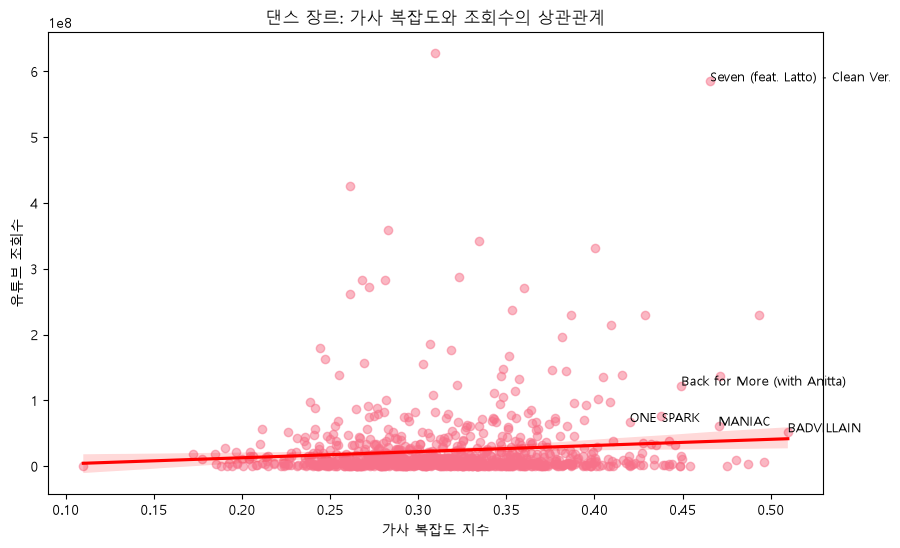

댄스 장르 가사 복잡도-조회수 상관계수: 0.1011


In [19]:
# ================================
# 1. 댄스 장르만 선택 (게임 OST 등 이상치는 1-1에서 이미 제외)
# ================================
dance_df = df_final[df_final['genie_genre'] == '댄스'].copy()

# ================================
# 2. 산점도 + 회귀선
# ================================
plt.figure(figsize=(10, 6))

sns.regplot(
    data=dance_df,
    x='lyrics_complexity_index',
    y='api_view_count',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

# ================================
# 3. 상위 복잡도 특이 케이스 표시 (상위 5%)
# ================================
outliers = dance_df[
    dance_df['lyrics_complexity_index'] >
    dance_df['lyrics_complexity_index'].quantile(0.95)
]

for i, row in outliers.head(5).iterrows():
    plt.text(
        row['lyrics_complexity_index'],
        row['api_view_count'],
        row['songName'],
        fontsize=9
    )

plt.title('댄스 장르: 가사 복잡도와 조회수의 상관관계')
plt.xlabel('가사 복잡도 지수')
plt.ylabel('유튜브 조회수')
plt.show()

# ================================
# 4. 상관계수 계산
# ================================
correlation = dance_df['lyrics_complexity_index'].corr(dance_df['api_view_count'])
print(f"댄스 장르 가사 복잡도-조회수 상관계수: {correlation:.4f}")

### 1-13. 가사 복잡도×감정 4분면 분석 제안
단순히 "무슨 단어를 썼나"가 아니라 "어떤 스타일의 곡이 돈이 되는가"를 보여주는 4분면(복잡도×감정) 프레임을 제안합니다.

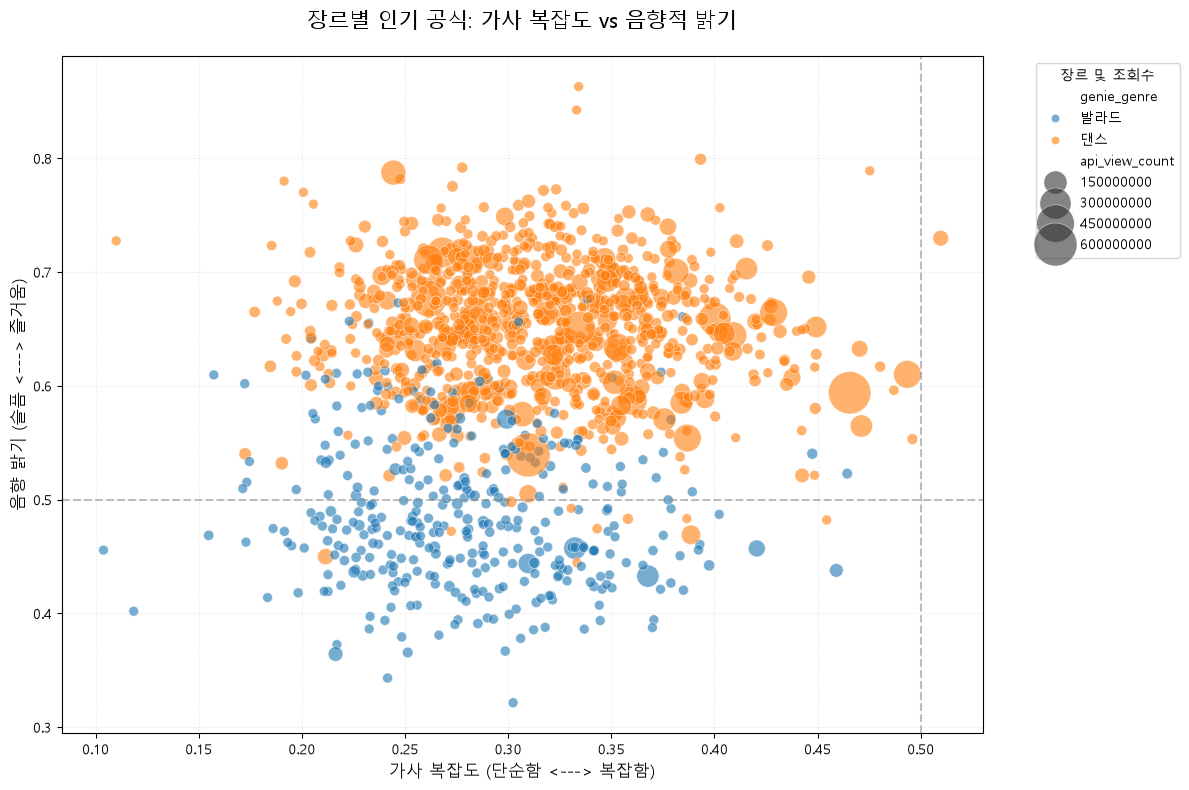

In [20]:
plt.figure(figsize=(12, 8))

# 1. 시각화 대상 장르 필터링
target_genres = ['댄스', '발라드']
df_filtered = df_final[df_final['genie_genre'].isin(target_genres)]

# 2. 산점도 생성
# palette='Set1' 또는 직접 색상 지정 (예: {'댄스': '#FF6B6B', '발라드': '#4D96FF'})
sns.scatterplot(
    data=df_filtered,
    x='lyrics_complexity_index',
    y='valence_normalized',
    size='api_view_count',
    hue='genie_genre',
    palette={'댄스': '#ff7f0e', '발라드': '#1f77b4'}, # 댄스(주황), 발라드(파랑)로 명확히 구분
    alpha=0.6,
    sizes=(50, 1000), # 원의 크기 범위를 키워 흥행 곡을 더 잘 보이게 설정
    edgecolor='w',    # 원 테두리를 하얗게 설정하여 겹치는 부분 구분
    linewidth=0.5
)

# 3. 기준선 및 디자인 설정
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5) # 밝기 기준선
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5) # 복잡도 기준선

plt.title('장르별 인기 공식: 가사 복잡도 vs 음향적 밝기', fontsize=15, pad=20)
plt.xlabel('가사 복잡도 (단순함 <---> 복잡함)', fontsize=12)
plt.ylabel('음향 밝기 (슬픔 <---> 즐거움)', fontsize=12)

# 범례 위치 조정
plt.legend(title='장르 및 조회수', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

### 1-14. 발라드/R&B 영어 비율 확인
**분석**: 영어 비중 상위 20% 발라드/R&B 곡 확인.
**결과**: 발라드인데 영어 비중이 80%에 육박하는 곡들(로제, 베이비몬스터, 정국 등)이 존재 → 발라드 장르의 '글로벌화'를 보여주는 증거.

In [21]:
# 기준: 영어 비중 상위 20% 이상
threshold = df_final['english_ratio'].quantile(0.8)

high_english = df_final[
    (df_final['english_ratio'] >= threshold) &
    (df_final['genie_genre'].isin(['발라드', 'R&B/소울']))
].copy()

# 보기 좋은 컬럼만
cols = [
    'songName',
    'artists',
    'genie_genre',
    'english_ratio',
    'api_view_count'
]

result = high_english[cols].sort_values(by='english_ratio', ascending=False)

print(result.head(20))

                                songName  \
267                Peanut Butter & Tears   
842                            Big world   
126                               For Us   
651                      White Christmas   
560                                 Easy   
940                                  Bad   
1714                   What Would You Do   
754   Love Hangover (feat. Dominic Fike)   
211               Re: Thinkin' About You   
818                       Do What You Do   
1450         Sweet Dreams (feat. Miguel)   
0                        number one girl   
20                   Stuck In The Middle   
53                              Hate You   
961                            MONA LISA   
997                    Winter Wonderland   
1190                       SUPA DUPA LUV   
1243                               R.E.M   
1234                   Champagne Poppin’   
68                            Rainy Days   

                                                artists genie_genre  \
267 

### 1-15. 흥행 결정 요인 회귀분석 (Regression Analysis)
**분석**: 전체 데이터를 대상으로 조회수에 영향을 미치는 변수들의 회귀계수를 분석.
**결과 (2024년 대중가요 3대 흥행 원칙)**: ① 언어의 글로벌화(english_ratio가 가장 강력한 양의 예측변수) ② 구조의 단순화(lyrics_complexity_index는 전체 곡에서는 음의 계수이나 댄스·발라드에서는 양의 계수로 장르별로 다름) ③ 반복의 미학(repeated_token_ratio는 양의 계수). (단, 모델 설명력 R²는 전체 0.037·댄스 0.025·발라드 0.207로 낮아 참고용입니다.)

In [22]:
def run_regression_analysis(df, group_name):
    # 1. 분석 변수 선택 및 결측치 제거
    features = ['english_ratio', 'lyrics_complexity_index', 'repeated_token_ratio']
    target = 'api_view_count'

    analysis_df = df[features + [target]].dropna()

    # 2. 독립변수 표준화 (변수 간 단위가 다르므로 영향력 크기 비교를 위해 필수)
    scaler = StandardScaler()
    X = scaler.fit_transform(analysis_df[features])
    X = pd.DataFrame(X, columns=features)
    y = analysis_df[target].values

    # 3. 회귀 모델 학습 (OLS)
    X = sm.add_constant(X) # 절편 추가
    model = sm.OLS(y, X).fit()

    print(f"\n===== [{group_name}] 흥행 요인 영향력 분석 =====")
    # 각 변수의 계수(Coefficient)만 추출하여 영향력 비교
    coef_df = model.params[1:].sort_values(ascending=False)
    for feature, coef in coef_df.items():
        print(f"▶ {feature:25} 영향력 가중치: {coef:,.0f}")

    # R-squared (모델의 설명력)
    print(f"※ 모델 설명력(R-squared): {model.rsquared:.4f}")
    return model

# [전체], [댄스], [발라드] 각각 분석 실행
full_model = run_regression_analysis(df_final, "전체 곡")
dance_model = run_regression_analysis(df_final[df_final['genie_genre'] == '댄스'], "댄스")
ballad_model = run_regression_analysis(df_final[df_final['genie_genre'] == '발라드'], "발라드")


===== [전체 곡] 흥행 요인 영향력 분석 =====
▶ english_ratio             영향력 가중치: 12,866,401
▶ repeated_token_ratio      영향력 가중치: 504,349
▶ lyrics_complexity_index   영향력 가중치: -811,840
※ 모델 설명력(R-squared): 0.0366

===== [댄스] 흥행 요인 영향력 분석 =====
▶ english_ratio             영향력 가중치: 7,393,360
▶ lyrics_complexity_index   영향력 가중치: 879,175
▶ repeated_token_ratio      영향력 가중치: 665,899
※ 모델 설명력(R-squared): 0.0249

===== [발라드] 흥행 요인 영향력 분석 =====
▶ english_ratio             영향력 가중치: 5,442,708
▶ repeated_token_ratio      영향력 가중치: 1,458,350
▶ lyrics_complexity_index   영향력 가중치: 339,497
※ 모델 설명력(R-squared): 0.2068


### 1-16. 상관관계 히트맵

**분석**: 오디오(valence, arousal, energy, tempo 등)·감성·언어 지표를 모아 상관계수 행렬 히트맵 생성.

In [23]:
# 분석에 필요한 컬럼 리스트 정의
target_columns = [
    'genie_genre', 'valence_raw', 'arousal_raw', 'valence_normalized', 'arousal_normalized',
    'energy', 'loudness', 'tempo', 'duration_ms',
    'speechiness', 'acoustic_score', 'sentiment_compound',
    'sentiment_positive', 'sentiment_negative', 'sentiment_neutral',
    'avg_brightness', 'avg_motion', 'avg_r_value', 'avg_g_value', 'avg_b_value',
    'token_count', 'unique_token_ratio', 'repeated_token_ratio',
    'avg_token_length', 'hapax_legomenon', 'hapax_dislegomenon', 'hapax_trislegomenon',
    'unique_tokens_per_line', 'avg_tokens_per_line', 'line_count',
    'punctuation_ratio', 'compression_rate', 'pronoun_frequency',
    'korean_ratio', 'english_ratio', 'daily_view_count'
]

# 새로운 데이터프레임 생성
분석_df = df_final[target_columns].copy()

# 데이터 요약 정보 확인
print(분석_df.info())

<class 'pandas.DataFrame'>
Index: 2042 entries, 0 to 2042
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   genie_genre             2042 non-null   str    
 1   valence_raw             2042 non-null   float64
 2   arousal_raw             2042 non-null   float64
 3   valence_normalized      2042 non-null   float64
 4   arousal_normalized      2042 non-null   float64
 5   energy                  2042 non-null   float64
 6   loudness                2042 non-null   float64
 7   tempo                   2042 non-null   float64
 8   duration_ms             2042 non-null   float64
 9   speechiness             2042 non-null   float64
 10  acoustic_score          2042 non-null   float64
 11  sentiment_compound      2042 non-null   float64
 12  sentiment_positive      2042 non-null   float64
 13  sentiment_negative      2042 non-null   float64
 14  sentiment_neutral       2042 non-null   float64
 15  avg

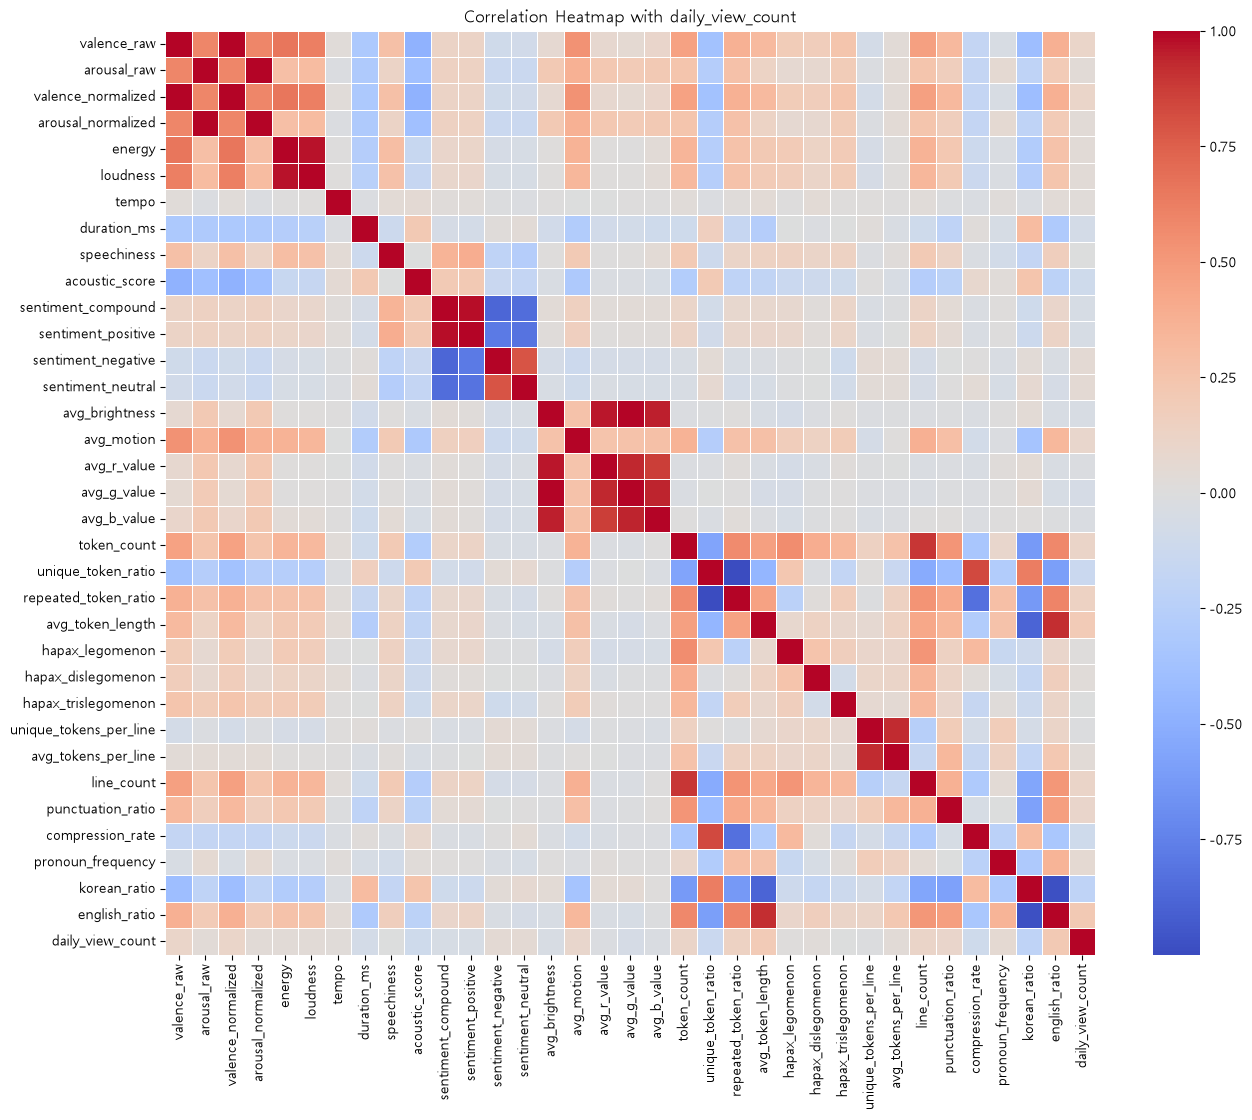

In [24]:
# 1. 수치형 컬럼들만 선택
numeric_df = 분석_df.select_dtypes(include=['float64', 'int64'])

# 2. 상관계수 행렬 계산
corr_matrix = numeric_df.corr()

# 3. daily_view_count와의 상관관계만 따로 정렬해서 보기 (선택 사항)
# print(corr_matrix['daily_view_count'].sort_values(ascending=False))

# 4. 히트맵 시각화
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap with daily_view_count')
plt.show()

### 1-17. 상관관계 상위 10개

**분석**: `daily_view_count`와 상관계수 절댓값 기준 상위 10개 변수만 추출, 장르별 `daily_view_count` 분포(로그 스케일)도 함께 확인.

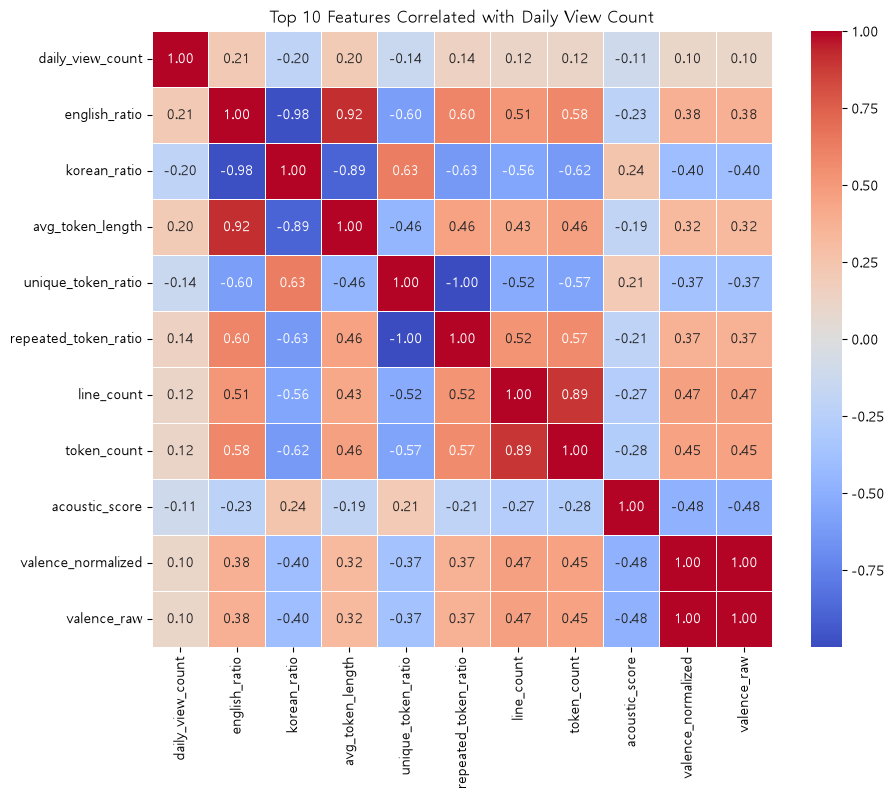

In [25]:
# 1. 수치형 데이터만 추출
numeric_df = 분석_df.select_dtypes(include=[np.number])

# 2. 모든 변수와 daily_view_count 간의 상관계수 계산
correlations = numeric_df.corr()['daily_view_count'].abs().sort_values(ascending=False)

# 3. 상위 11개 추출 (자기 자신인 daily_view_count 포함)
top_10_features = correlations.head(11).index
top_10_corr_matrix = numeric_df[top_10_features].corr()

# 4. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(top_10_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Top 10 Features Correlated with Daily View Count')
plt.show()

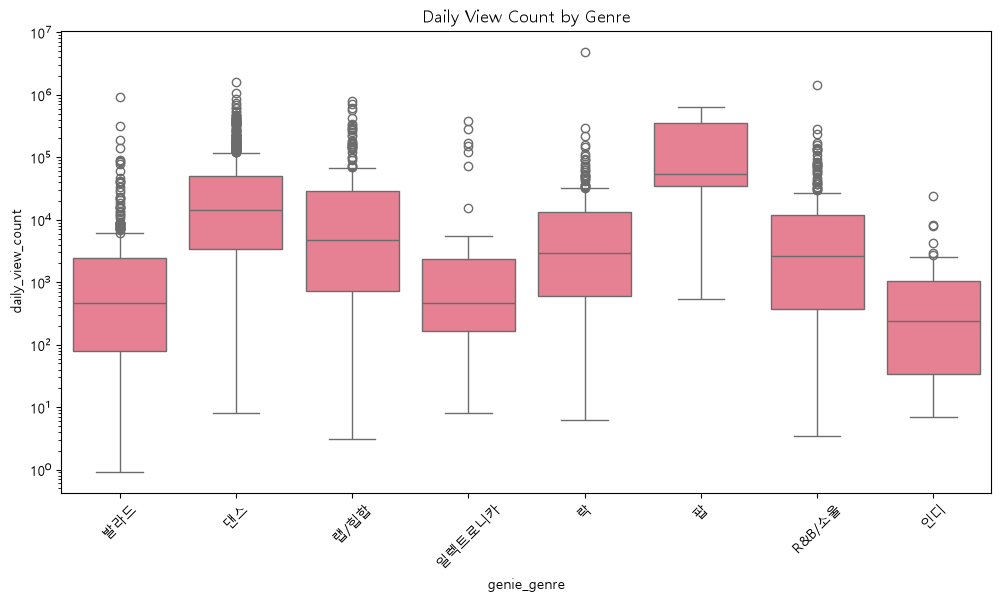

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='genie_genre', y='daily_view_count', data=df_final)
plt.xticks(rotation=45)
plt.title('Daily View Count by Genre')
plt.yscale('log') # 조회수 편차가 크다면 로그 스케일로 보는 것이 좋습니다.
plt.show()

### 1-18. 장르별 핵심 오디오 특징 (레이더차트용 데이터)

**분석**: energy, valence, arousal, speechiness, acoustic_score의 장르별 평균값을 계산해 레이더차트용 프로필 데이터 생성.

--- 장르별 오디오 특징 평균 프로필 ---
               energy  valence_normalized  arousal_normalized  speechiness  \
genie_genre                                                                  
R&B/소울       0.243809            0.562155            0.562330     0.201457   
댄스           0.272690            0.651394            0.595728     0.282007   
락            0.249779            0.627472            0.564058     0.227918   
랩/힙합         0.266926            0.604570            0.547414     0.298684   
발라드          0.202309            0.486385            0.495736     0.147661   
인디           0.220938            0.525103            0.529599     0.148250   
일렉트로니카       0.273147            0.641352            0.543622     0.280625   
팝            0.245306            0.615704            0.567601     0.284133   

             acoustic_score  
genie_genre                  
R&B/소울             0.588788  
댄스                 0.556509  
락                  0.566048  
랩/힙합               0.568188  
발라드          

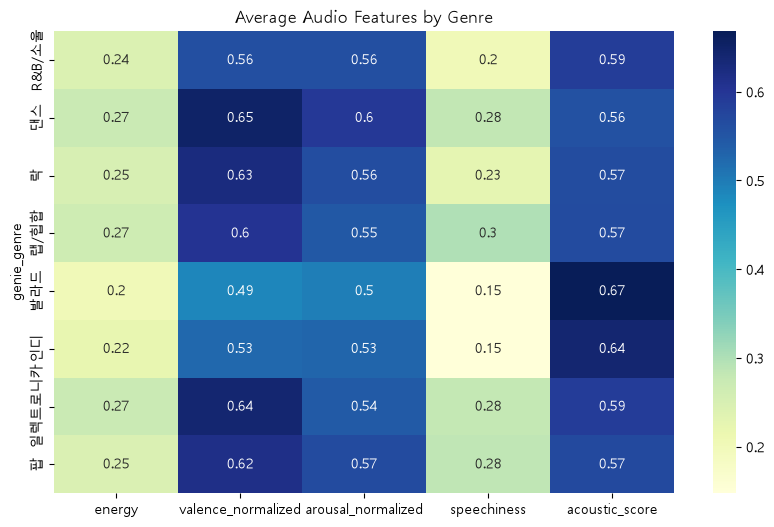

In [27]:
# 분석할 주요 특징 선택 (정규화된 값 위주)
features_to_compare = ['energy', 'valence_normalized', 'arousal_normalized', 'speechiness', 'acoustic_score']

# 장르별 평균값 계산
genre_profile = 분석_df.groupby('genie_genre')[features_to_compare].mean()

# 결과 확인
print("--- 장르별 오디오 특징 평균 프로필 ---")
print(genre_profile)

# 간단한 히트맵으로 장르별 특징 차이 보기
plt.figure(figsize=(10, 6))
sns.heatmap(genre_profile, annot=True, cmap='YlGnBu')
plt.title('Average Audio Features by Genre')
plt.show()